In [1]:
import sys
import os

#sys.path.insert(0, os.path.abspath('/home/vk9342/scarlet2/src'))

import scarlet2
print(scarlet2.__file__) # This confirms it's loading from your home directory

/home/vk9342/.conda/envs/usrp/lib/python3.11/site-packages/jaxtyping/__init__.py:231: UserWarning: jaxtyping version >=0.2.23 should be used with Equinox version >=0.11.1
  warnings.warn(
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


/home/vk9342/.conda/envs/usrp/lib/python3.11/site-packages/scarlet2/__init__.py


In [2]:
import numpy as np
import numpyro.distributions as dist
from numpyro.distributions import constraints, Distribution

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
matplotlib.rc('image', cmap='gray', interpolation='none', origin='lower')

import jax


import jax.numpy as jnp
from jax import random, jit
import jax
import copy

import pandas as pd
from scipy.stats import gaussian_kde as kde
from scipy.stats import norm

# import scarlet
import scarlet2
# from scarlet.display import AsinhMapping,AsinhPercentileNorm,show_scarlet2_scene,LinearPercentileNorm
# from scarlet.source import StaticSource,MultiExtendedSource, StaticMultiExtendedSource
from scarlet2 import *
from scarlet2 import relative_step
from scarlet2 import (
    Observation, Frame, Scene, Source, PointSource,
    init, relative_step, Parameter, StaticArraySpectrum, 
    TransientArraySpectrum
)
from scarlet2 import Starlet
from scarlet2.plot import AsinhPercentileNorm


import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.time import Time
from astropy.wcs import WCS
from astropy.io import fits
import astropy.io.fits as fits

import sys
import copy
#import corner
import h5py
import os
import glob
import sep
from sep import Background, extract
import tarfile
import equinox as eqx
# import distrax
import optax
from tqdm.auto import tqdm
# import cmasher as cmr


from functools import partial
from skimage import draw
%matplotlib inline
# import astrophot as ap
pixelscale=0.17

# turn on automatic validation checks
from scarlet2.validation_utils import set_validation

# turn on automatic validation checks
set_validation(False)

# Load the Data + Define Observation and Frame: 
#### Get Rubin + 2 Roman data
get files and psfs, based on RubinRoman_TD-lc.ipynb \\

In [3]:
# ============================================================================
# 1. General File
# ============================================================================
# img_index = 1952
img_index = 216276  #50421 #170330 #50421 #157804 #111827 #209546 #216276 #62425 #1125     #72358 #154919 # 12486 #1952  #17462 #96679
# date = '29_06_26'
oversamplefactor = 1
rubin_psf_type = 'realPSF' #or 'realPSF'

if img_index == 96679:
    t_start = 5
    t_end = 120
    # version = '_v16'


elif img_index == 17462:
    t_start = 20
    t_end = 130
    # version = '_v5'
elif img_index == 72358:
    t_start = 20
    t_end = 130
    # version = '_v6'

# elif img_index == 1125:
#     t_start = 10
#     t_end = 130
#     version = '_v1'
# elif img_index == 89052:
#     t_start = 10
#     t_end = 130
#     version = '_v1'
elif img_index == 62425:
    t_start = 5
    t_end = 130
    # version = '_v9'
elif img_index == 216276:
    t_start = 5
    t_end = 130
    # version = '_v6'
elif img_index == 209546:
    t_start = 10
    t_end = 130
    # version = '_v6'


elif img_index == 111827:
    t_start = 5
    t_end = 130
    # version = '_v6'
elif img_index == 64783:
    t_start = 10
    t_end = 130
    # version = '_v6'
elif img_index == 157804:
    t_start = 10
    t_end = 130
    # version = '_v7'



elif img_index == 50421:
    t_start = 10
    t_end = 120
    # version = '_v6'
elif img_index == 2737:
    t_start = 10
    t_end = 120
    # version = '_v6'
elif img_index == 170330:
    t_start = 5
    t_end = 120
    # version = '_v6'




t_off   = 0
t_on    = 48
n_roman_epochs = 2


times = [0, 10, 20, 30, 36, 40, 44, 48, 50, 56, 60, 70, 80, 100, 130, 140]

# times = [0, 8, 10, 16, 20, 24, 30, 34, 38, 40, 44, 48, 52, 56, 60, 68, 76, 80, 90, 110, 130, 140]

# times = [0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48, 52, 56, 60, 64, 68, 72, 76, 80, 86, 90, 100, 110, 120, 130, 140]


epochs = [int(i) for i in range(len(times))] # basically just list of index keys correspond to each time?

path = 'outputs/caustics/SNsims/'
# data_path  = path + 'img_' + str(img_index) + '/fixed_rgb/'
data_path  = path + 'img_' + str(img_index) + '/apj_paper/'
psf_path   = 'PSFs/'

bands   = ["g","r","i"]
BANDS   = ['f106', 'f129',  'f158']    #['f106', 'f087',  'f062']     #['f106', 'f129',  'f158']  #['G', 'R', 'I']
bandall = ['g','r','i', 'f106', 'f129',  'f158']      #['g','r','i','G','R','I']

channels = []
channels_on = []
observations = []
epochs_on = []

n_lsst  = len(bands) * len(times)   # e.g. 3 bands × (len(times))
n_roman  = len(BANDS) * n_roman_epochs   # 3 bands × 2 epochs = 6


In [4]:
## ============================================================================
## Get weights: copied function from caustics (which is based on lenstronomy)
## ============================================================================
telescope_params = {
    'LSST': {
        'read_noise': 10.0,
        'pixel_scale': 0.2, 
        'ccd_gain': 2.3,
        'exposure_time': {'g': 15.0, 'r': 15.0, 'i': 15.0},
        'sky_brightness_mags': {'g': 22.26, 'r': 21.2, 'i': 20.48},
        'zero_points_mags': {'g': 28.30, 'r': 28.13, 'i': 27.79},
        'num_exposures': {'g': 200, 'r': 460, 'i': 460},
        'seeing': {'g':0.77, 'r':0.73, 'i':0.71}
    },
    'Roman': {
        'read_noise': 15.5,
        'pixel_scale': 0.11, 
        'ccd_gain': 1,
        'sky_brightness_mags': {'f062': 23.19, 'f087': 22.93, 'f106':22.99, 'f129':22.99, 'f158':23.10, 'f184':23.22, 'f146':22.03},
        'zero_points_mags': {'f062':26.6179, 'f087': 26.3023, 'f106': 26.3546, 'f129':26.3531, 'f158':26.3760, 'f184':25.9124, 'f146':27.5842},
        'seeing': {'f062': 0.058, 'f087':0.073, 'f106':0.087, 'f129': 0.106, 'f158':0.128, 'f184':0.146, 'f146':0.105},
       
        'exposure_time': {'f062':60, 'f087': 85, 'f106': 95, 'f129': 152, 'f158': 294, 'f184': None, 'f146':None},
        'num_exposures':  {'f062':1, 'f087': 1,   'f106': 1,   'f129': 1,   'f158': 1,   'f184': None, 'f146':None}
    }
}

def gaussian_noise_sigma(
    image, 
    readout_noise,   # have read noise param value,     in counts (e.g. e-)?
    exposure_time,   # have exposure time param value,  in seconds?
    sky_brightness,  # have sky brightness param value, in magnitudes/arcsec^2
    pixel_scale,     # have pixel scale param value,    in arcsec
    num_exposures,   # have num exposures param value,  unitless
    magnitude_zero_point
):
    '''
    background_noise: Gaussian sigma of noise level per pixel in counts (e- or ADU) per second.
    Im assuming we're using e- and not ADU???
    '''
    
    # Convert Sky Magnitude to Counts/sec/arcsec^2 (conversion from Lenstronomy)
    sky_brightness_counts_arcsec2 = 10 ** (-(sky_brightness - magnitude_zero_point) / 2.5)

    exposure_time_tot = num_exposures * exposure_time
    readout_noise_tot = num_exposures * readout_noise**2  # square of readout noise
    sky_per_pixel = sky_brightness_counts_arcsec2 * pixel_scale**2
    sky_brightness_tot = exposure_time_tot * sky_per_pixel
    
    sigma_bkg = np.sqrt(readout_noise_tot + sky_brightness_tot) / exposure_time_tot

    return sigma_bkg


In [5]:
# ============================================================================
# 3. Load Observations for each Rubin epoch
# ============================================================================
for ind_b, band in enumerate(bands):
    for ind_t, epoch in enumerate(times):
        channel_sc2 = (band, int(ind_t)) 

        if epoch == t_on:
            ind_t_on = str(ind_t)
        elif epoch == t_off:
            ind_t_off = str(ind_t)
        
        # get channels for only 'on' times
        if epoch >= t_start and epoch <t_end:  
            channels_on.append(channel_sc2)
            epochs_on.append(int(ind_t))
        
        # Caustics image simulation files (fits)
        data_file_name = f'image_LSST_{band}_{str(img_index)}_SNnoise_{rubin_psf_type}{str(epoch)}.0.fits' 
        img = data_path+ data_file_name

        obs_hdu = fits.open(img)
        data_lsst = obs_hdu[0].data
        data_lsst = data_lsst.astype(data_lsst.dtype.newbyteorder('=')) ## Do I sill need this?
        N1, N2 = data_lsst.shape
        data_lsst = data_lsst.reshape(1, N1, N2) #reshape because?

        # WCS - saved as headerof fits files, made manually in Caustics
        wcs_lsst = WCS(obs_hdu[0].header)

        # PSF data - npy files with gaussians, made manually in Caustics
        # psf_data = np.load(psf_path + f'caustics_gaussian_psf_LSST_{band}_size_17.npy')
        if rubin_psf_type == 'gausPSF':
            psf_data = np.load(psf_path + f'caustics_gaussian_psf_LSST_{band}.npy')
        elif rubin_psf_type == 'realPSF':
            if band == 'g':
                psf_data = np.load(psf_path + f'cutout_{band}_70_PSF.npy')
            elif band == 'r':
                psf_data = np.load(psf_path + f'cutout_{band}_337_PSF.npy')
            elif band == 'i':
                psf_data = np.load(psf_path + f'cutout_{band}_657_PSF.npy')
            else:
                print('psf band??')
        else:
            print('rubin psf file?')
                
        
        psf_jax = jnp.asarray([psf_data.astype('float32')]/np.sum(psf_data.astype('float32')))
        psf_lsst = scarlet2.ArrayPSF(psf_jax)

        
        ## Recalculate added noise (added on top of Caustics image before saving .fits files)
        params = telescope_params['LSST']
        noise_sigma = gaussian_noise_sigma(
            image = data_lsst,
            readout_noise = params['read_noise'],
            exposure_time = params['exposure_time'][band],
            sky_brightness = params['sky_brightness_mags'][band],
            pixel_scale = params['pixel_scale'],
            num_exposures = params['num_exposures'][band],
            magnitude_zero_point = params['zero_points_mags'][band]
        )
        weights_lsst = jnp.ones_like(data_lsst) / (noise_sigma**2)
        # print(noise_sigma)
       
        # Make observation
        obs_lsst = scarlet2.Observation(jnp.asarray(data_lsst),
                                      wcs=wcs_lsst,
                                      psf=psf_lsst,
                                      channels=[channel_sc2],
                                      weights=weights_lsst)
        observations.append(obs_lsst)
        channels.append(channel_sc2)


In [6]:
print(wcs_lsst)

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 0.0 0.0 
CRPIX : 15.5 15.5 
PC1_1 PC1_2  : -5.5555555555556e-05 0.0 
PC2_1 PC2_2  : 0.0 5.5555555555556e-05 
CDELT : 1.0 1.0 
NAXIS : 30  30


In [7]:
# ============================================================================
# 5. Load high-res off/on images for Roman
# ============================================================================

#Read in a single epoch of high resolution imaging WITHOUT the SN
for ind_b, (band, BAND) in enumerate(zip(bands, BANDS)):

    channel_sc2 = (BAND, int(ind_t_off))
    epoch = t_off
    
    data_file_name = 'image_Roman_'+BAND+'_'+str(img_index)+'_SNnoise_gausPSF'+str(t_off)+'.0.fits' 
    img = data_path+ data_file_name

    obs_hdu = fits.open(img)
    data_roman = obs_hdu[0].data
    data_roman = data_roman.astype(data_roman.dtype.newbyteorder('=')) ## Do I sill need this?
    N1, N2 = data_roman.shape
    data_roman = data_roman.reshape(1, N1, N2) #reshape because?
    wcs_roman = WCS(obs_hdu[0].header)

    psf_data = np.load(psf_path + f'caustics_gaussian_psf_Roman_{BAND}.npy')
    psf_jax = jnp.asarray([psf_data.astype('float32')]/np.sum(psf_data.astype('float32')))
    psf_roman = scarlet2.ArrayPSF(psf_jax)

    ## Recalculate added noise
    params = telescope_params['Roman']
    noise_sigma = gaussian_noise_sigma(
        image = data_roman,
        readout_noise = params['read_noise'],
        exposure_time = params['exposure_time'][BAND],
        sky_brightness = params['sky_brightness_mags'][BAND],
        pixel_scale = params['pixel_scale'],
        num_exposures = params['num_exposures'][BAND],
        magnitude_zero_point = params['zero_points_mags'][BAND]
    )
    weights_roman = jnp.ones_like(data_roman) / (noise_sigma**2)
    print(noise_sigma)

    # define two observation packages and match to frame
    obs_roman_offSN = scarlet2.Observation(data_roman,
                                   wcs=wcs_roman,
                                   psf=psf_roman,
                                   channels=[channel_sc2],
                                   weights= weights_roman) #should weights be none?    
    
    channels.append(channel_sc2)
    observations.append(obs_roman_offSN)



#Read in a single epoch of high resolution imaging WITH the SN

for ind_b, (band, BAND) in enumerate(zip(bands, BANDS)):
    
    channel_sc2 = (BAND, int(ind_t_on))
    epoch = t_on
    
    data_file_name = 'image_Roman_'+BAND+'_'+str(img_index)+'_SNnoise_gausPSF'+str(t_on)+'.0.fits' 
    img = data_path+ data_file_name

    obs_hdu = fits.open(img)
    data_roman = obs_hdu[0].data
    data_roman = data_roman.astype(data_roman.dtype.newbyteorder('=')) ## Do I sill need this?
    N1, N2 = data_roman.shape
    data_roman = data_roman.reshape(1, N1, N2) #reshape because?
    wcs_roman = WCS(obs_hdu[0].header)
    print(wcs_roman)
    # data_roman_offSN = jnp.array(np.asarray(data_roman,dtype=float), jnp.float32)

    psf_data = np.load(psf_path + f'caustics_gaussian_psf_Roman_{BAND}.npy')
    psf_jax = jnp.asarray([psf_data.astype('float32')]/np.sum(psf_data.astype('float32')))
    psf_roman = scarlet2.ArrayPSF(psf_jax)
    print(np.sum(psf_roman))
    ## Recalculate added noise
    params = telescope_params['Roman']
    noise_sigma = gaussian_noise_sigma(
        image = data_roman,
        readout_noise = params['read_noise'],
        exposure_time = params['exposure_time'][BAND],
        sky_brightness = params['sky_brightness_mags'][BAND],
        pixel_scale = params['pixel_scale'],
        num_exposures = params['num_exposures'][BAND],
        magnitude_zero_point = params['zero_points_mags'][BAND]
    )
    weights_roman = jnp.ones_like(data_roman) / (noise_sigma**2)
    print(noise_sigma)
    

    channels_on.append(channel_sc2)
    epochs_on.append(int(ind_t_on))
    
    # define two observation packages and match to frame
    obs_roman_postSN = scarlet2.Observation(jnp.asarray(data_roman),
                                   wcs=wcs_roman,
                                   psf=psf_roman,
                                   channels=[channel_sc2],
                                   weights=weights_roman) #should weights be none? 
    
    channels.append(channel_sc2)
    observations.append(obs_roman_postSN)


0.17159469598490368
0.11027849283278497
0.06017137680885486
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 0.0 0.0 
CRPIX : 28.0 28.0 
PC1_1 PC1_2  : -3.0555555555556e-05 0.0 
PC2_1 PC2_2  : 0.0 3.0555555555556e-05 
CDELT : 1.0 1.0 
NAXIS : 55  55
ArrayPSF(morphology=f32[1,5,5])
0.17159469598490368
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 0.0 0.0 
CRPIX : 28.0 28.0 
PC1_1 PC1_2  : -3.0555555555556e-05 0.0 
PC2_1 PC2_2  : 0.0 3.0555555555556e-05 
CDELT : 1.0 1.0 
NAXIS : 55  55
ArrayPSF(morphology=f32[1,5,5])
0.11027849283278497
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 0.0 0.0 
CRPIX : 28.0 28.0 
PC1_1 PC1_2  : -3.0555555555556e-05 0.0 
PC2_1 PC2_2  : 0.0 3.0555555555556e-05 
CDELT : 1.0 1.0 
NAXIS : 55  55
ArrayPSF(morphology=f32[1,5,5])
0.06017137680885486


In [8]:
#How many observations did we end up reading in? Should be at least a few
print(len(observations))
print(channels)
bandind = np.unique([x[0] for x in channels],return_index=True)

print(bandind[1])


54
[('g', 0), ('g', 1), ('g', 2), ('g', 3), ('g', 4), ('g', 5), ('g', 6), ('g', 7), ('g', 8), ('g', 9), ('g', 10), ('g', 11), ('g', 12), ('g', 13), ('g', 14), ('g', 15), ('r', 0), ('r', 1), ('r', 2), ('r', 3), ('r', 4), ('r', 5), ('r', 6), ('r', 7), ('r', 8), ('r', 9), ('r', 10), ('r', 11), ('r', 12), ('r', 13), ('r', 14), ('r', 15), ('i', 0), ('i', 1), ('i', 2), ('i', 3), ('i', 4), ('i', 5), ('i', 6), ('i', 7), ('i', 8), ('i', 9), ('i', 10), ('i', 11), ('i', 12), ('i', 13), ('i', 14), ('i', 15), ('f106', 0), ('f129', 0), ('f158', 0), ('f106', 7), ('f129', 7), ('f158', 7)]
[48 49 50  0 32 16]


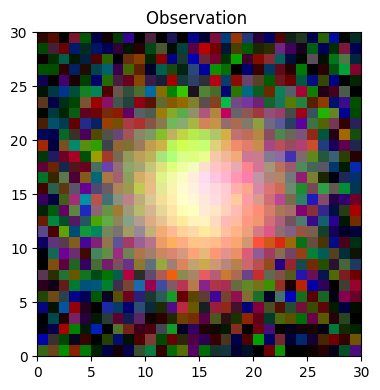

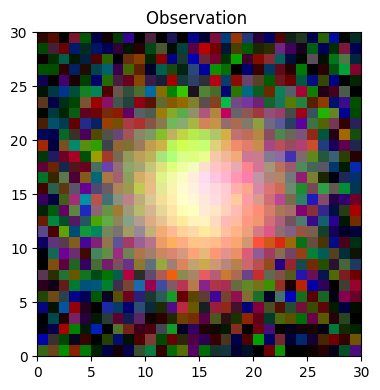

In [9]:
### PLOT OBSERVTION IN RGB ####
rgb_data = []
rgb_weights = []
rgb_psfs = []
rgb_channels = []
rgb_wcs = None

target_epoch = times[8] 
for band in bands: # Standard RGB bands
    data_file_name = f'image_LSST_{band}_{img_index}_SNnoise_{target_epoch}.0.fits'
    img_path = data_path + data_file_name
    with fits.open(img_path) as hdul:
        if band == 'g':
            rgb_wcs = WCS(hdul[0].header)

        d = hdul[0].data.astype('float32')
        rgb_data.append(d)
        params = telescope_params['LSST']
        noise_sigma = gaussian_noise_sigma(
            image=d,
            readout_noise=params['read_noise'],
            exposure_time=params['exposure_time'][band],
            sky_brightness=params['sky_brightness_mags'][band],
            pixel_scale=params['pixel_scale'],
            num_exposures=params['num_exposures'][band],
            magnitude_zero_point=params['zero_points_mags'][band]
        )
        rgb_weights.append(np.ones_like(d) / (noise_sigma**2))
        rgb_psf_data = np.load(psf_path + f'caustics_gaussian_psf_LSST_{band}_size_17.npy')
        rgb_psf_norm = rgb_psf_data.astype('float32') / np.sum(rgb_psf_data)
        rgb_psfs.append(scarlet2.ArrayPSF(jnp.array(rgb_psf_norm)))
        rgb_channels.append((band, target_epoch))
        
rgb_combined_obs = scarlet2.Observation(
    jnp.array(rgb_data),
    weights=jnp.array(rgb_weights),
    psf=rgb_psfs[0],
    wcs=rgb_wcs,
    channels=rgb_channels
)
norm = scarlet2.plot.AsinhAutomaticNorm(rgb_combined_obs)
scarlet2.plot.observation(rgb_combined_obs, norm=norm, add_labels=False, show_psf=False)
# plt.savefig(f'paper_plots/{img_index}_rgb_lensing_noise_lsst_{target_epoch}.png')



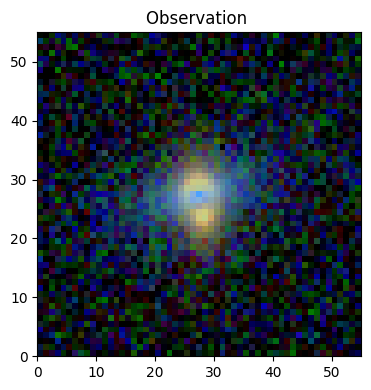

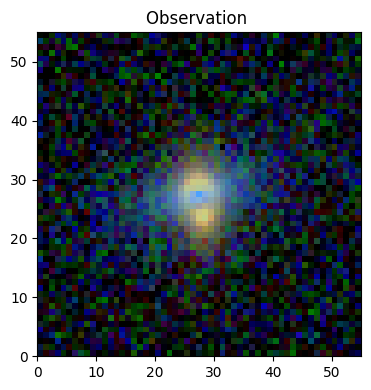

In [10]:
### PLOT OBSERVTION IN RGB ####
rgb_data = []
rgb_weights = []
rgb_psfs = []
rgb_channels = []
rgb_wcs = None

target_epoch = times[0] 
for band in BANDS: # Standard RGB bands
    data_file_name = f'image_Roman_{band}_{img_index}_SNnoise_{target_epoch}.0.fits'
    img_path = data_path + data_file_name
    with fits.open(img_path) as hdul:
        if band == BANDS[0]: #'g':
            rgb_wcs = WCS(hdul[0].header)

        d = hdul[0].data.astype('float32')
        rgb_data.append(d)
        params = telescope_params['Roman']
        noise_sigma = gaussian_noise_sigma(
            image=d,
            readout_noise=params['read_noise'],
            exposure_time=params['exposure_time'][band],
            sky_brightness=params['sky_brightness_mags'][band],
            pixel_scale=params['pixel_scale'],
            num_exposures=params['num_exposures'][band],
            magnitude_zero_point=params['zero_points_mags'][band]
        )
        rgb_weights.append(np.ones_like(d) / (noise_sigma**2))
        rgb_psf_data = np.load(psf_path + f'caustics_gaussian_psf_Roman_{band}_size_17.npy')
        rgb_psf_norm = rgb_psf_data.astype('float32') / np.sum(rgb_psf_data)
        rgb_psfs.append(scarlet2.ArrayPSF(jnp.array(rgb_psf_norm)))
        rgb_channels.append((band, target_epoch))
        
rgb_combined_obs = scarlet2.Observation(
    jnp.array(rgb_data),
    weights=jnp.array(rgb_weights),
    psf=rgb_psfs[0],
    wcs=rgb_wcs,
    channels=rgb_channels
)
norm = scarlet2.plot.AsinhAutomaticNorm(rgb_combined_obs)
scarlet2.plot.observation(rgb_combined_obs, norm=norm, add_labels=False, show_psf=False)
# plt.savefig(f'paper_plots/{img_index}_rgb_lensing_noise_roman_{target_epoch}.png')



In [11]:
# ============================================================================
# 6. Make Frame and match observations
# ============================================================================
# model_frame_psf = scarlet2.GaussianPSF(0.7)
model_frame = scarlet2.Frame.from_observations(
    observations=observations,
    model_psf = scarlet2.GaussianPSF(sigma = 0.5),
    coverage="union"  # or "intersection"
    )

for obs in observations:
    obs.match(model_frame)

### Find Sources

In [12]:
# ============================================================================
# 7. Find sourced in image - from RubinRoman_TD notebook
# ============================================================================

def makeCatalog(observations, lvl=3, wave=True, SNR=2.0):
    
    normed_images = np.asarray([obs.data[0] for obs in observations])
    interps = normed_images
    
    interps = np.asarray(interps/np.sum(interps))
    detect_image = np.sum(interps,axis=(0))
    # Wavelet transform
    # wave_detect = scarlet.Starlet.from_image(detect_image).coefficients
    wave_detect = Starlet.from_image(detect_image).coefficients

    if wave:
        # Creates detection from the first 3 wavelet levels
        detect = wave_detect[:lvl,:,:].sum(axis = 0)
    else:
        detect = detect_image

    detect = np.array(detect)

    # Runs SEP detection
    bkg = sep.Background(detect)
    catalog = sep.extract(detect-bkg.globalback, SNR, err=bkg.globalrms)
    background=[]
    bg_rms=[]
    for ind in range(len(observations)):
        img = copy.copy(np.asarray(observations[ind].data))
        if np.size(img.shape) == 3:
            bg_rms.append(np.array([sep.Background(band).globalrms for band in img]))
            background.append(np.array([sep.Background(band).globalback for band in img]))
        else:
            bg_rms.append(sep.Background(img).globalrms)
            background.append(sep.Background(img).globalback)
    return catalog, bg_rms, detect_image, background

In [13]:
# ============================================================================
# 8. Find sources in image - from RubinRoman_TD notebook
# USE ROMAN IMAGES ONLY
# ============================================================================

#If the source detection is not finding all the sources, you can first try to adjust these three parameters to help it find the sources
lvl=2
wave=2
SNR=5.0  # was 2

lsst_obs = observations[:-n_roman]
roman_obs = observations[-n_roman:]

observations_sc2=[]
normsingle=[]

# ============================================================================   
# DETECT SOURCES BASED ONLY ON ROMAN IMGS

catalog_single_roman, bgsingle_roman, detectsingle_roman, globalback_roman = makeCatalog(roman_obs, lvl, wave, SNR)
pixel = np.stack((catalog_single_roman['y'], catalog_single_roman['x']), axis=1)
ra_dec = pixel
print(ra_dec.shape)
# ============================================================================

(2, 2)


In [14]:
#################################################################################
### MAKE observations_sc2 ###########################

bgarr_roman     = np.asarray(bgsingle_roman)
bgarrall_roman  = np.hstack((bgarr_roman.flatten(),np.asarray(bgsingle_roman).flatten()))
bgarr_roman     = np.asarray(bgsingle_roman)
print(bgarrall_roman.shape)

catalog_single_lsst, bgsingle_lsst, detectsingle_lsst, globalback_lsst = makeCatalog(lsst_obs, lvl, wave, SNR)
bgarr_lsst    = np.asarray(bgsingle_lsst)
bgarrall_lsst = np.hstack((bgarr_lsst.flatten(),np.asarray(bgsingle_lsst).flatten()))
bgarr_lsst    = np.asarray(bgsingle_lsst)
print(bgarrall_lsst.shape)


bgr_lsst = np.array([b[0] for b in bgarr_lsst])
bgr_roman = np.array([b[0] for b in bgarr_roman])
bgarr_all = np.concatenate([bgr_lsst, bgr_roman], axis=0)

gb_lsst = np.array([b[0] for b in globalback_lsst])
gb_roman = np.array([b[0] for b in globalback_roman])
globalback_all = np.concatenate([gb_lsst, gb_roman], axis=0)

print(len(bgarr_all))
print(len(globalback_all))


for ind,(obs2, bg, back) in enumerate(zip(observations, bgarr_all, globalback_all)):

    print(ind)
    
    w = obs2.frame.wcs
    psf = obs2.frame.psf
    weights2=np.ones(obs2.data.shape) / (bg**2)#[:, None, None]  #??in RubinRoman notebook insteads of bg it uses bgarr_all, is this a typo?
    data = obs2.data-back   #Subtract background flux

    print(channels[ind])
    
    obs_sc2 = scarlet2.Observation(jnp.asarray(data), jnp.asarray(weights2), psf=psf,channels=[channels[ind]],wcs=w)
    observations_sc2.append(obs_sc2)
    # print("obs2.data shape:", obs2.data.shape, '\n')
    # print('obs2.data: ', obs2.data, '\n')
    # print('obs2.data[:,10:-10,10:-10]:', obs2.data[:,10:-10,10:-10], '\n')

    
    #Store norm based on observation data
    normsingle.append(
        AsinhPercentileNorm(
            jnp.asarray(np.asarray((obs2.data[:,10:-10,10:-10]),dtype=np.float32)),
            percentiles=[0.001, 50, 80])
    )



(12,)
(96,)
54
54
0
('g', 0)
1
('g', 1)
2
('g', 2)
3
('g', 3)
4
('g', 4)
5
('g', 5)
6
('g', 6)
7
('g', 7)
8
('g', 8)
9
('g', 9)
10
('g', 10)
11
('g', 11)
12
('g', 12)
13
('g', 13)
14
('g', 14)
15
('g', 15)
16
('r', 0)
17
('r', 1)
18
('r', 2)
19
('r', 3)
20
('r', 4)
21
('r', 5)
22
('r', 6)
23
('r', 7)
24
('r', 8)
25
('r', 9)
26
('r', 10)
27
('r', 11)
28
('r', 12)
29
('r', 13)
30
('r', 14)
31
('r', 15)
32
('i', 0)
33
('i', 1)
34
('i', 2)
35
('i', 3)
36
('i', 4)
37
('i', 5)
38
('i', 6)
39
('i', 7)
40
('i', 8)
41
('i', 9)
42
('i', 10)
43
('i', 11)
44
('i', 12)
45
('i', 13)
46
('i', 14)
47
('i', 15)
48
('f106', 0)
49
('f129', 0)
50
('f158', 0)
51
('f106', 7)
52
('f129', 7)
53
('f158', 7)


In [15]:
# ## Debugging inhomogeneous part
# for i, obs in enumerate(observations):
#     print(f"Index {i} -> obs.data[0] shape: {obs.data[0].shape}")

In [16]:
# import astropy.units as u
# from scarlet2.frame import get_pixel_size, get_psf_size


# all_psf_details = []
# for c, obs in enumerate(observations_sc2):
#     h_obs = get_pixel_size(obs.frame.wcs)
#     if isinstance(h_obs, u.Quantity):
#         h_obs = h_obs.to(u.arcsec).value
        
#     psf_morphs = obs.frame.psf.morphology
    
#     for ch_idx, psf_ch in enumerate(psf_morphs):
#         size_arcsec = get_psf_size(psf_ch) * h_obs
#         all_psf_details.append({
#             'obs_id': c,
#             'band': obs.frame.channels[ch_idx],
#             'size_arcsec': size_arcsec,
#             'h_obs': h_obs
#         })

# best_obs = min(all_psf_details, key=lambda x: x['size_arcsec'])

# print(f"--- PSF Analysis ---")
# for item in all_psf_details:
#     print(f"Obs {item['obs_id']} [{item['band']}]: {item['size_arcsec']:.4f} arcsec")

# print(f"\nSmallest PSF found in: Obs {best_obs['obs_id']} ({best_obs['band']})")
# print(f"Size: {best_obs['size_arcsec']:.4f} arcseconds")

In [17]:
model_frame = scarlet2.Frame.from_observations(
    observations=observations_sc2,
    model_psf = scarlet2.GaussianPSF(sigma = 0.3),  #0.3358681664775348
    coverage="union",  # or "intersection"
)


In [18]:
print(model_frame)

wcs_roman_oversampled = copy.deepcopy(model_frame.wcs)
wcs_roman_oversampled.wcs.crpix = model_frame.wcs.wcs.crpix*oversamplefactor 
wcs_roman_oversampled.wcs.pc = model_frame.wcs.wcs.pc/oversamplefactor 
wcs_roman_oversampled._naxis[-1] = model_frame.wcs._naxis[-1]*oversamplefactor
wcs_roman_oversampled._naxis[-2] = model_frame.wcs._naxis[-2]*oversamplefactor

bbox_roman_oversampled = copy.deepcopy(model_frame.bbox)
# bbox_roman_oversampled.shape = (bbox_roman_oversampled.shape[-3],bbox_roman_oversampled.shape[-2]*oversamplefactor,bbox_roman_oversampled.shape[-1]*oversamplefactor)

#print(wcs_roman_oversampled)
object.__setattr__(model_frame,'wcs', wcs_roman_oversampled)
object.__setattr__(model_frame,'bbox', bbox_roman_oversampled)
print(model_frame)

norm_corr = []
for i, obs in enumerate(observations_sc2):
    # if i<n_lsst:
    #     obs_corr = scarlet2.CorrelatedObservation.from_observation(obs,resample_to_frame=model_frame)#,resample_psf=True)
    # else:
    #     obs_corr = scarlet2.CorrelatedObservation.from_observation(obs,resample_to_frame=model_frame,resample_psf=False,lanczos_order=21)
    obs_corr = scarlet2.CorrelatedObservation.from_observation(obs,resample_to_frame=model_frame, resample_psf=True)
    norm_c= scarlet2.plot.AsinhAutomaticNorm(obs_corr)
    norm_corr.append(norm_c)
    
    obs_corr.match(model_frame)
    observations_sc2[i] = obs_corr

Frame(
  bbox=Box(shape=(54, 55, 55), origin=(0, 0, 0)),
  psf=GaussianPSF(morphology=GaussianMorphology(size=0.3, ellipticity=None)),
  wcs=WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 0.0 0.0 
CRPIX : 28.0 28.0 
PC1_1 PC1_2  : -3.0555555555556e-05 0.0 
PC2_1 PC2_2  : 0.0 3.0555555555556e-05 
CDELT : 1.0 1.0 
NAXIS : 55  55,
  channels=[
    ('g', 0),
    ('g', 1),
    ('g', 2),
    ('g', 3),
    ('g', 4),
    ('g', 5),
    ('g', 6),
    ('g', 7),
    ('g', 8),
    ('g', 9),
    ('g', 10),
    ('g', 11),
    ('g', 12),
    ('g', 13),
    ('g', 14),
    ('g', 15),
    ('r', 0),
    ('r', 1),
    ('r', 2),
    ('r', 3),
    ('r', 4),
    ('r', 5),
    ('r', 6),
    ('r', 7),
    ('r', 8),
    ('r', 9),
    ('r', 10),
    ('r', 11),
    ('r', 12),
    ('r', 13),
    ('r', 14),
    ('r', 15),
    ('i', 0),
    ('i', 1),
    ('i', 2),
    ('i', 3),
    ('i', 4),
    ('i', 5),
    ('i', 6),
    ('i', 7),
    ('i', 8),
    ('i', 9),
    ('i', 10),
    ('i', 11),

### Initialize Sources

In [111]:
# ============================================================================
# 10. Source initialization
# ============================================================================
lsst_obs_sc2 = observations_sc2[:-n_roman]
roman_obs_sc2 = observations_sc2[-n_roman:]

band_selector  = lambda ch: ch[0]
epoch_selector = lambda ch: ch[1]


In [112]:
# ============================================================================
# 9. Get and visualize sources in image
# ============================================================================
world_coords = []
for y, x in ra_dec:
    sky = wcs_roman.pixel_to_world(x, y)   # note: pixel_to_world(x, y)
    world_coords.append(SkyCoord(sky.ra, sky.dec))

roman_pixel_coords = [wcs_roman.world_to_pixel(sky) for sky in world_coords]
lsst_pixel_coords = [wcs_lsst.world_to_pixel(sky) for sky in world_coords]

## Ra and dec centers from SEP catalog
sky_coords_ = world_coords

In [113]:
print("Detected source pixel coordinates:")
for i, (y, x) in enumerate(ra_dec, start=1):
    print(f"  Source {i:>2d}: x = {x:.2f}, y = {y:.2f}")

print("\nDetected source sky coordinates:")
for i, sky in enumerate(world_coords, start=1):
    # in decimal degrees:
    print(f"  Source {i:>2d}: RA = {sky.ra.deg:.6f}°,  Dec = {sky.dec.deg:.6f}°")

print("\nBack to LSST pixel coords:")
for i, (x_lsst, y_lsst) in enumerate(lsst_pixel_coords, start=1):
    print(f" Source {i}:  x = {x_lsst:.2f},  y = {y_lsst:.2f}")

print("\nBack to Roman pixel coords:")
for i, (x_roman, y_roman) in enumerate(roman_pixel_coords, start=1):
    print(f" Source {i}:  x = {x_roman:.2f},  y = {y_roman:.2f}")


Detected source pixel coordinates:
  Source  1: x = 28.00, y = 23.09
  Source  2: x = 26.84, y = 27.73

Detected source sky coordinates:
  Source  1: RA = 359.999969°,  Dec = -0.000119°
  Source  2: RA = 0.000005°,  Dec = 0.000022°

Back to LSST pixel coords:
 Source 1:  x = 15.05,  y = 12.35
 Source 2:  x = 14.41,  y = 14.90

Back to Roman pixel coords:
 Source 1:  x = 28.00,  y = 23.09
 Source 2:  x = 26.84,  y = 27.73


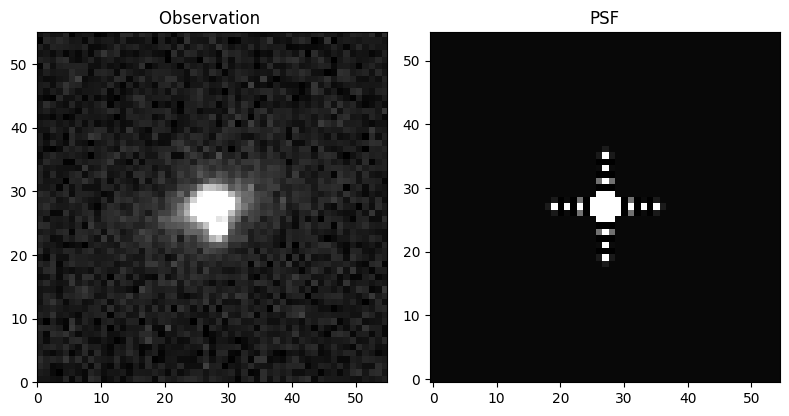

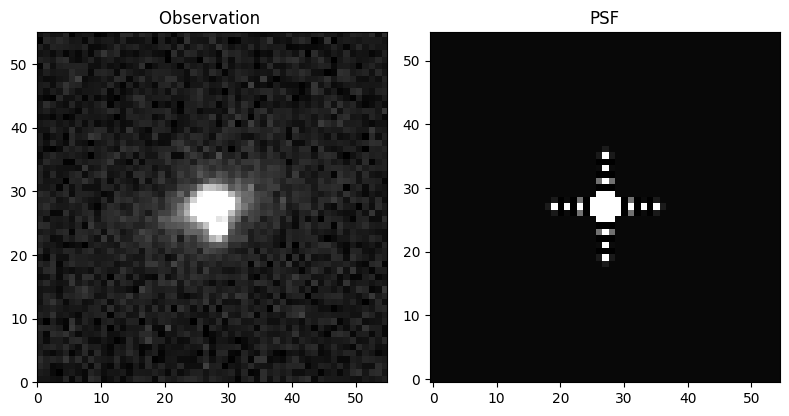

"\n# get current axis\nax = plt.gca()\n\n# loop over sources and draw both red circle and index label\nfor i, (x0, y0) in enumerate(roman_pixel_coords):\n    x0, y0 = float(x0), float(y0)\n\n    # Draw red circle\n    ax.scatter(\n        x0, y0,\n        s=80,\n        edgecolors='red',\n        facecolors='none',\n        linewidths=2\n    )\n\n    # Add index label\n    ax.text(\n        x0, y0,\n        str(i),\n        color='red',\n        fontsize=5,\n        ha='center',\n        va='center',\n        weight='bold'\n    )\n\nplt.show()\n"

In [114]:
# draw the observation into the current axes
lsst_obs_sc2 = observations_sc2[:-n_roman]
roman_obs_sc2 = observations_sc2[-n_roman:]

scarlet2.plot.observation(
    observation=observations_sc2[51],
    norm=None,
    channel_map=None,
    show_psf=True,
    add_labels=False,
)
# save_path = f'{img_index}_results/{date}/sc2_prefitting/'
# plt.savefig(save_path+ str(img_index)+'_observation_lsst'+version+'.png')
plt.show()


scarlet2.plot.observation(
    observation=observations_sc2[51],
    norm=None,
    channel_map=None,
    show_psf=True,
    add_labels=False,
)
# save_path = f'{img_index}_results/{date}/sc2_prefitting/'
# plt.savefig(save_path+ str(img_index)+'_observation_roman'+version+'.png')
plt.show()

#plt.imshow(np.log(observations[53].frame.psf()[0]))
#plt.show()
'''
# get current axis
ax = plt.gca()

# loop over sources and draw both red circle and index label
for i, (x0, y0) in enumerate(roman_pixel_coords):
    x0, y0 = float(x0), float(y0)

    # Draw red circle
    ax.scatter(
        x0, y0,
        s=80,
        edgecolors='red',
        facecolors='none',
        linewidths=2
    )

    # Add index label
    ax.text(
        x0, y0,
        str(i),
        color='red',
        fontsize=5,
        ha='center',
        va='center',
        weight='bold'
    )

plt.show()
'''

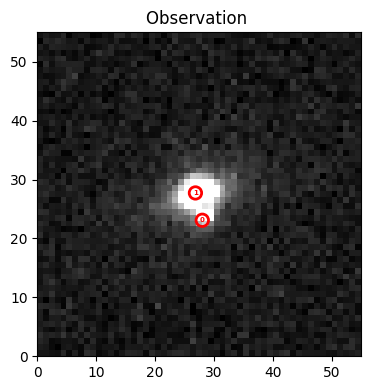

In [115]:
scarlet2.plot.observation(
    observation=observations_sc2[51],
    norm=None,
    channel_map=None,
    show_psf=False,
    add_labels=False,
)
#plt.imshow(np.log(observations[53].frame.psf()[0]))
#plt.show()
# get current axis
ax = plt.gca()

# loop over sources and draw both red circle and index label
for i, (x0, y0) in enumerate(roman_pixel_coords):
    x0, y0 = float(x0), float(y0)

    # Draw red circle
    ax.scatter(
        x0, y0,
        s=80,
        edgecolors='red',
        facecolors='none',
        linewidths=2
    )

    # Add index label
    ax.text(
        x0, y0,
        str(i),
        color='red',
        fontsize=5,
        ha='center',
        va='center',
        weight='bold'
    )

plt.show()


In [116]:
# ## Debugging inhomogeneous part
# for i, obs in enumerate(observations):
#     print(f"Index {i} -> obs.data[0] shape: {obs.data[0].shape}")

In [117]:
# ============================================================================
# 10.2 Get coords of source in center of image (assume it is the lens)
# ============================================================================

'''
Modify sources based on system
--> adapt list sky_coords
--> adapt is extended
'''

#### Check if in center of image:
roman_obs_sc2_on = roman_obs_sc2[-1]
_, H, W   = roman_obs_sc2_on.data.shape               # data.shape = (C, H, WT
center_pix = np.array([W//2, H//2], dtype=int)        # [x_center, y_center] in Roman coords
tol_pix    = 3                                        # how close (in px) counts as “at centre”
is_center = []


center_pix_sky = wcs_roman.pixel_to_world(center_pix[0], center_pix[1])
center_pix_sky_coords = SkyCoord(center_pix_sky.ra, center_pix_sky.dec)
# print(center_pix_sky_coords, '\n')
# print(sky_coords_, '\n')


for i, roman_pix_coords in enumerate(roman_pixel_coords):
    is_center.append(np.all(np.abs(roman_pix_coords - center_pix) <= tol_pix))
    print(f"Source {i} at pixel {roman_pix_coords}, centre is {center_pix}, is_center={is_center[i]}")
print('is_center: ', is_center, '\n')


sky_coords = sky_coords_ #+ [center_pix_sky_coords]

#17462 #96679 #1952
if img_index == 96679:
    if BANDS == ['G', 'R', 'I']:
        new_source_pixel_x = 27
        new_source_pixel_y = 28
        new_sky_coord = wcs_roman.pixel_to_world(new_source_pixel_x, new_source_pixel_y)
        sky_coords = sky_coords + [new_sky_coord] # add PS at same location as 3rd source ie lens
        del sky_coords[1]   # delete second source on host to the left
        is_extended = [True, True, False, False]
        lens_indx = 1

    elif BANDS == ['f106', 'f129', 'f158']:
        del sky_coords[1]   # delete second source on host to the left
        new_source_pixel_x = 26
        new_source_pixel_y = 27
        new_sky_coord = wcs_roman.pixel_to_world(new_source_pixel_x, new_source_pixel_y)
        sky_coords = sky_coords + [new_sky_coord] # add PS at same location as 3rd source ie lens
        is_extended = [True, True, False, False]
        lens_indx = 1
    
    elif BANDS == ['f106', 'f087', 'f062']:
        del sky_coords[2]   # delete second source on host to the left
        new_source_pixel_x = 27
        new_source_pixel_y = 27
        new_sky_coord = wcs_roman.pixel_to_world(new_source_pixel_x, new_source_pixel_y)
        sky_coords = sky_coords + [new_sky_coord] # add PS at same location as 3rd source ie lens
        is_extended = [False, True, False, True]
        lens_indx = 3


elif img_index == 50421:
    del sky_coords[3]
    is_extended = [False, True, True, False]
    lens_indx = 2
elif img_index == 2737:
    del sky_coords[1]
    is_extended = [False, True, False, True]
    lens_indx = 1
elif img_index == 170330:
    is_extended = [True, False, True, False]
    lens_indx = 2

elif img_index == 157804:
    new_source_pixel_x = 27
    new_source_pixel_y = 27
    new_sky_coord = wcs_roman.pixel_to_world(new_source_pixel_x, new_source_pixel_y)
    sky_coords = sky_coords + [new_sky_coord] # add PS at same location as 3rd source ie lens
    is_extended = [False, True, True, False]
    lens_indx = 2

elif img_index == 62425:
    # del sky_coords[2]
    sky_coords = sky_coords + [sky_coords[0]] # add PS at same location as 3rd source ie lens
    is_extended = [True, True, False, False]
    lens_indx = 0


elif img_index == 216276:
    # new_source_pixel_x = 27
    # new_source_pixel_y = 27
    # new_sky_coord = wcs_roman.pixel_to_world(new_source_pixel_x, new_source_pixel_y)
    sky_coords = sky_coords + [sky_coords[0], sky_coords[1]] # add PS at same location as 3rd source ie lens
    is_extended = [True, True, False, False]
    lens_indx = 2


elif img_index == 209546:
    sky_coords = sky_coords + [sky_coords[0], sky_coords[1]] 
    is_extended = [True, True, False, False]
    lens_indx = 1


    




print(sky_coords, '\n')
for i, sky_coord in enumerate(sky_coords):
    print(f"Source {i} at pixel {wcs_lsst.world_to_pixel(sky_coord)}, centre is {center_pix}")

print(is_extended)
    

Source 0 at pixel (array(28.00344779), array(23.0934652)), centre is [27 27], is_center=False
Source 1 at pixel (array(26.83926252), array(27.73116199)), centre is [27 27], is_center=True
is_center:  [False, True] 

[<SkyCoord (ICRS): (ra, dec) in deg
    (359.99996934, -0.00011937)>, <SkyCoord (ICRS): (ra, dec) in deg
    (4.91142303e-06, 2.23410609e-05)>, <SkyCoord (ICRS): (ra, dec) in deg
    (359.99996934, -0.00011937)>, <SkyCoord (ICRS): (ra, dec) in deg
    (4.91142303e-06, 2.23410609e-05)>] 

Source 0 at pixel (array(15.05189628), array(12.35140586)), centre is [27 27]
Source 1 at pixel (array(14.41159439), array(14.9021391)), centre is [27 27]
Source 2 at pixel (array(15.05189628), array(12.35140586)), centre is [27 27]
Source 3 at pixel (array(14.41159439), array(14.9021391)), centre is [27 27]
[True, True, False, False]


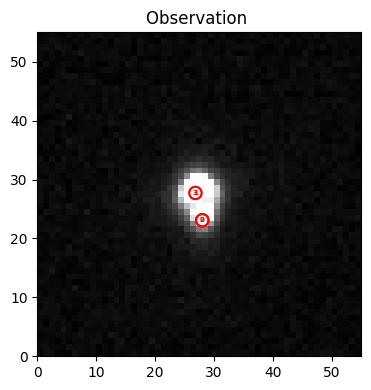

In [118]:
scarlet2.plot.observation(
    observation=observations[50],
    norm=None,
    channel_map=None,
    show_psf=False,
    add_labels=False,
)

# get current axis
ax = plt.gca()

# # loop over sources and draw both red circle and index label
for i, sky_coord_i in enumerate(sky_coords):
    x0, y0 = wcs_roman.world_to_pixel(sky_coord_i)
    x0, y0 = float(x0), float(y0)

    # Draw red circle
    if i ==3:
        ax.scatter(
            x0, y0,
            s=80,
            edgecolors='red',
            facecolors='none',
            linewidths=1
    )
    else:  
        ax.scatter(
            x0, y0,
            s=80,
            edgecolors='red',
            facecolors='none',
            linewidths=1.5
        )

    # Add index label
    if i ==3:
        ax.text(
            x0, y0,
            str(i),
            color='red',
            fontsize=5,
            ha='center',
            va='center',
            weight='bold'
        )
    else:
        ax.text(
            x0, y0,
            str(i),
            color='red',
            fontsize=5,
            ha='center',
            va='center',
            weight='bold'
        )

# save_path = f'{img_index}_results/{date}/sc2_prefitting/'
# plt.savefig(save_path+ str(img_index)+'_source_detection_lsst'+version+'.png')
plt.show()

In [119]:
print(channels)
# print(epochs)
print(channels_on)
print(bandind)

[('g', 0), ('g', 1), ('g', 2), ('g', 3), ('g', 4), ('g', 5), ('g', 6), ('g', 7), ('g', 8), ('g', 9), ('g', 10), ('g', 11), ('g', 12), ('g', 13), ('g', 14), ('g', 15), ('r', 0), ('r', 1), ('r', 2), ('r', 3), ('r', 4), ('r', 5), ('r', 6), ('r', 7), ('r', 8), ('r', 9), ('r', 10), ('r', 11), ('r', 12), ('r', 13), ('r', 14), ('r', 15), ('i', 0), ('i', 1), ('i', 2), ('i', 3), ('i', 4), ('i', 5), ('i', 6), ('i', 7), ('i', 8), ('i', 9), ('i', 10), ('i', 11), ('i', 12), ('i', 13), ('i', 14), ('i', 15), ('f106', 0), ('f129', 0), ('f158', 0), ('f106', 7), ('f129', 7), ('f158', 7)]
[('g', 1), ('g', 2), ('g', 3), ('g', 4), ('g', 5), ('g', 6), ('g', 7), ('g', 8), ('g', 9), ('g', 10), ('g', 11), ('g', 12), ('g', 13), ('r', 1), ('r', 2), ('r', 3), ('r', 4), ('r', 5), ('r', 6), ('r', 7), ('r', 8), ('r', 9), ('r', 10), ('r', 11), ('r', 12), ('r', 13), ('i', 1), ('i', 2), ('i', 3), ('i', 4), ('i', 5), ('i', 6), ('i', 7), ('i', 8), ('i', 9), ('i', 10), ('i', 11), ('i', 12), ('i', 13), ('f106', 7), ('f129'

In [120]:
def gaus2d(x=0, y=0, mx=0, my=0, sx=1, sy=1):
    return 1. / (2. * np.pi * sx * sy) * np.exp(-((x - mx)**2. / (2. * sx**2.) + (y - my)**2. / (2. * sy**2.)))

In [121]:
# def subtract_gaussian_at(morph, center_yx, sigma, amplitude_fraction=0.2):
#     """Subtract a scaled Gaussian profile from `morph` at `center_yx`.
#     Used to remove (most of) the central lens flux from the host stamp
#     before Starlet decomposition."""
#     h, w = morph.shape
#     yy, xx = np.mgrid[:h, :w].astype("float32")
#     cy, cx = center_yx
#     rr2 = (yy - cy) ** 2 + (xx - cx) ** 2
#     gauss = np.exp(-0.5 * rr2 / sigma**2).astype("float32")

#     iy = int(np.clip(round(cy), 0, h - 1))
#     ix = int(np.clip(round(cx), 0, w - 1))
#     peak = float(morph[iy, ix])
#     if peak <= 0 or not np.isfinite(peak):
#         return morph

#     subtracted = morph - gauss * peak * amplitude_fraction
#     subtracted = np.clip(subtracted, 0.0, None)
#     subtracted[subtracted < 1e-8] = 1e-8
#     subtracted /= subtracted.sum()
#     return subtracted.astype("float32")

In [122]:
# def gaussian_moments_to_sersic(morphology):
#     """
#     Estimate SersicMorphology initialization parameters from a 2D Gaussian-moment image.
    
#     Parameters
#     ----------
#     morphology: np.ndarray
#         2D image array (e.g. from from_gaussian_moments or gaus2d)
    
#     Returns
#     -------
#     size: float
#         Effective radius in pixels
#     e1, e2: float
#         Ellipticity components in e1/e2 convention
#     """
#     h, w = morphology.shape
#     yy, xx = np.mgrid[:h, :w].astype(float)
#     total = morphology.sum()
#     y0 = (morphology * yy).sum() / total
#     x0 = (morphology * xx).sum() / total
#     dy = yy - y0
#     dx = xx - x0
#     Ixx = (morphology * dx**2).sum() / total
#     Iyy = (morphology * dy**2).sum() / total
#     Ixy = (morphology * dx * dy).sum() / total
#     sigma = np.sqrt(0.5 * (Ixx + Iyy))
#     r_eff = float(max(sigma * 1.1774, 0.5))
#     denom = Ixx + Iyy + 2 * np.sqrt(np.maximum(Ixx * Iyy - Ixy**2, 0))
#     e1 = float((Ixx - Iyy) / denom) if denom > 0 else 0.0
#     e2 = float(2 * Ixy / denom) if denom > 0 else 0.0
#     return r_eff, e1, e2

In [123]:
# # ============================================================================
# # 10.3 Source initialization (point vs extended + Gaussian‐moment sizes)
# # ============================================================================
# ## Build the Scarlet Scene with one Source per detection


# with Scene(model_frame) as scene:
#     for i, coords  in enumerate(sky_coords):

#         ##############################################################        
#         ##############################################################
#         ## EXTENDED SOURCE (e.g. host galaxy) 
#         if is_extended[i]:
#             print(f"Source {i}: EXTENDED ")
#             if i == lens_indx: 
#                 print('lens')
#             else:
#                 print('host')
#             try: 
#                 print('trying from_gaussian_moments')
#                 x0_roman, y0_roman = wcs_roman_oversampled.world_to_pixel(coords)
#                 x0_roman, y0_roman = float(x0_roman), float(y0_roman)
#                 spectrum_roman, morphology_roman = init.from_gaussian_moments(
#                     roman_obs_sc2, 
#                     coords,
#                     min_snr = 4
#                 )
#                 morphology = morphology_roman
                
#             ## Use compact_morphology if gaussian moments fails
#             except IndexError:
#                 print('Using gaus2d')
#                 x = np.linspace(-20, 20, 40)
#                 y = np.linspace(-20, 20, 40)
#                 x, y = np.meshgrid(x, y) # get 2D variables instead of 1D
#                 morphology = gaus2d(x, y, sx=3, sy=3)

#             try:
#                 x0_lsst, y0_lsst = wcs_lsst.world_to_pixel(coords)
#                 x0_lsst, y0_lsst = float(x0_lsst), float(y0_lsst)
#                 spectrum_lsst, morphology_lsst = init.from_gaussian_moments(
#                     lsst_obs_sc2, 
#                     coords,#(x0_lsst, y0_lsst),
#                     min_snr = 5
#                 )
#             except:
#                 spectrum_lsst = init.pixel_spectrum(lsst_obs_sc2, coords)
#                 #spectrum_roman = init.pixel_spectrum(roman_obs_sc2, coords)



#             print('morphology.shape before padding: ', morphology.shape)            
#             # initialize Morphology
#             if i == lens_indx:                      #lens
#                 pad = int((15 - morphology.shape[0])/2)
#                 # if sersic_lens == True:
#                 #     # ── Sersic morphology for lens ──────────────────────────────
#                 #     r_eff, e1, e2 = gaussian_moments_to_sersic(morphology)
#                 #     initial_size = max(r_eff, 0.5)
#                 #     initial_ellipticity = jnp.array([e1, e2])
#                 #     initial_n = 0.5  # matches Gaussian assumption of from_gaussian_moments
    
#                 #     morph = scarlet2.SersicMorphology(
#                 #         n=initial_n,
#                 #         size=initial_size,
#                 #         ellipticity=initial_ellipticity,
#                 #         shape=(25, 25), 
#                 #     )
                    
#                 #     print(f'lens Sersic init: size={initial_size:.3f}, e1={e1:.3f}, e2={e2:.3f}, n={initial_n}')
#                 #     ──────────────────────────────
            
#             else:                     
#                 pad = int((20 - morphology.shape[0])/2)
#             #     # if sersic_lens == True:
#             #     #     #──────────────────────────────
#             #     #     print('morphology.shape before padding: ', morphology.shape)
#             #     #     pad = int((50 - morphology.shape[0]) / 2)
#             #     #     pad = np.clip(pad, a_min=0, a_max=100)
#             #     #     morph = np.pad(morphology, (pad, pad), 'constant')
#             #     #     morph[morph < 1e-8] = 1e-8
#             #     #     morph = scarlet2.StarletMorphology.from_image(morph, min_value=1e-8)
#             #     #     print('morphology.shape after padding: ', morph.shape)
#             #     #     # ──────────────────────────────
            
#             pad = np.clip(pad, a_min=0, a_max = 100)
#             morph = np.pad(morphology,(pad, pad), 'constant')
#             morph[morph<1e-8]=1e-8
            
            
#             # # if i != lens_indx:   # fi want to remove lens from host
#             # #     LENS_SIGMA_PIX = 4.0
#             # #     # Host: subtract the lens's central profile, now that the
#             # #     # stamp is centered on the lens position too
#             # #     stamp_center = (morph.shape[0] - 1) / 2.0
#             # #     lens_pos_in_stamp = (stamp_center, stamp_center)
#             # #     morph = subtract_gaussian_at(morph, lens_pos_in_stamp, LENS_SIGMA_PIX, amplitude_fraction=0.3)
            

            
#             # # morph = scarlet2.StarletMorphology.from_image(morph)
#             morph = scarlet2.StarletMorphology.from_image(morph, min_value=1e-8)
#             # morph = jnp.asarray(morph)  # If not using starlet
#             print('morphology.shape after padding: ', morph.shape)
            
#             ## join lsst and roman fluxes
#             g_0, r_0, i_0 = spectrum_lsst[0], spectrum_lsst[16], spectrum_lsst[32]   # First 'g'
#             f106_0, f129_0, f158_0 = spectrum_roman[0], spectrum_roman[1], spectrum_roman[2]
#             fluxes = np.array([g_0, r_0, i_0, 
#                                f106_0, f129_0, f158_0])
#                                # 0.1 * f106_0, 0.1 * f129_0, 0.1 * f158_0])
                        
#             fluxes[fluxes<1e-6]=1e-6
#             print(fluxes,bandall)
            
#             ## Fit StaticArraySpectrum to source
#             static_spectrum = scarlet2.StaticArraySpectrum(
#                     fluxes,
#                     bands=bandall,
#                     band_selector=band_selector
#                 )  
#             scarlet2.Source(coords, static_spectrum, morph)
        
        
        
        
        
#         ########################################################################
#         # POINT SOURCE (transient/SN) —
#         else:
#             print(f"Source {i}: POINT SOURCE")
#             spectrum_lsst = init.pixel_spectrum(lsst_obs_sc2, coords)  #coords in sky coords ?, include correct_psf ?
#             spectrum_roman = init.pixel_spectrum(roman_obs_sc2, coords)  #coords in sky coords ?, include correct_psf ?
#             # print(len(spectrum_lsst))
#             # the above returns arrays containing fluxes for ALL images, but sets the roman/lsst image fluxes to 0 in spectrum_lsst/roman
#             spectrum_lsst = spectrum_lsst[:n_lsst]
#             spectrum_roman = spectrum_roman[n_lsst:]
#             flux_var = np.hstack((spectrum_lsst, spectrum_roman))
#             flux_var[flux_var<1e-6]=np.median(flux_var)  
#             flux_var[np.isnan(flux_var)]=1e-6

#             # Set off epoch flux to 0 (small value)
#             for j, (band, epoch) in enumerate(channels):
#                 if epoch not in epochs_on:
#                     flux_var[j] = 1e-20  # Or 0.0 
#                 # if epoch in epochs_on:
#                     # flux_var[j] = flux_var[j] * 10
    
#             flux = jnp.asarray(flux_var)
#             print(flux)
            
#             transient_spectrum = scarlet2.TransientArraySpectrum(
#                     flux,
#                     epochs=epochs_on,  #epochs, # all epochs or channels_zeroed?
#                     epoch_selector=epoch_selector
#                 )
#             scarlet2.PointSource(coords, transient_spectrum)
            

# # By now `scene.sources` contains your point/transient sources and extended source(s).
# print(scene)


In [133]:
# ============================================================================
# 13. Source initialization (point vs extended + Gaussian‐moment sizes)
# ============================================================================
## Build the Scarlet Scene with one Source per detection


with Scene(model_frame) as scene:
    for i, coords  in enumerate(sky_coords):

        # ============================================================================
        # EXTENDED SOURCE (e.g. host and lens galaxy) 
        if is_extended[i]:
            
            print(f"Source {i}: EXTENDED ")
            if i == lens_indx: 
                print('lens')
            else:
                print('host')
            try: 
                print('trying from_gaussian_moments')
                x0_roman, y0_roman = wcs_roman_oversampled.world_to_pixel(coords)
                x0_roman, y0_roman = float(x0_roman), float(y0_roman)
                spectrum_roman, morphology_roman = init.from_gaussian_moments(
                    roman_obs_sc2, 
                    coords,
                    min_snr = 4,
                    box_sizes=[30, 25] if i == lens_indx else [25, 25]
                )
                morphology = morphology_roman
                
            ## Use gaus2d if gaussian moments fails; modify size as needed
            except IndexError:
                print('Using gaus2d')
                if i == lens_indx:
                    x = np.linspace(-20, 20, 40)
                    y = np.linspace(-20, 20, 40)
                    x, y = np.meshgrid(x, y) # get 2D variables instead of 1D
                    morphology = gaus2d(x, y, sx=2,sy=2) 
                        
                else:
                    x = np.linspace(-20, 20, 40)
                    y = np.linspace(-20, 20, 40)
                    x, y = np.meshgrid(x, y) # get 2D variables instead of 1D
                    morphology = gaus2d(x, y, sx=3, sy=3)
                    

            try:
                x0_lsst, y0_lsst = wcs_lsst.world_to_pixel(coords)
                x0_lsst, y0_lsst = float(x0_lsst), float(y0_lsst)
                spectrum_lsst, morphology_lsst = init.from_gaussian_moments(
                    lsst_obs_sc2, 
                    coords,#(x0_lsst, y0_lsst),
                    min_snr = 5
                )
            except:
                spectrum_lsst = init.pixel_spectrum(lsst_obs_sc2, coords)
                #spectrum_roman = init.pixel_spectrum(roman_obs_sc2, coords)

            
            print('morphology.shape before padding: ', morphology.shape)
           
            # Pad source boxes if too small
            if i == lens_indx:                      
                pad = int((25 - morphology.shape[0])/2)
            else:     
                pad = int((25 - morphology.shape[0])/2)
            
            pad = np.clip(pad, a_min=0, a_max = 100)
            morph = np.pad(morphology,(pad, pad), 'constant')
            morph[morph<1e-8]=1e-8
            # morph = scarlet2.StarletMorphology.from_image(morph, min_value=1e-8)    # --> more stable fitting, but not tested yet, may need some modifications to run properly
            morph = jnp.asarray(morph)
            
            print('morphology.shape after padding: ', morph.shape)
            
            ## join lsst and roman fluxes
            # fluxes = np.hstack((spectrum_lsst,0.1*spectrum_roman))[:6]#[bandind[1]]  
            g_0, r_0, i_0 = spectrum_lsst[0], spectrum_lsst[16], spectrum_lsst[32]
            f106_0, f129_0, f158_0 = spectrum_roman[0], spectrum_roman[1], spectrum_roman[2]
            fluxes = np.array([g_0, r_0, i_0, 
                               0.1 * f106_0, 0.1 * f129_0, 0.1 * f158_0])
                               # f106_0, f129_0, f158_0])
                        
            fluxes[fluxes<1e-6]=1e-6
            print(fluxes,bandall)
            
            ## Fit StaticArraySpectrum to source
            static_spectrum = scarlet2.StaticArraySpectrum(
                    fluxes,
                    bands=bandall,
                    band_selector=band_selector
                )  
            scarlet2.Source(coords, static_spectrum, morph)
        
        # ============================================================================
        # POINT SOURCE (transient/SN) —
        else:
            print(f"Source {i}: POINT SOURCE")
            spectrum_lsst = init.pixel_spectrum(lsst_obs_sc2, coords)  
            spectrum_roman = init.pixel_spectrum(roman_obs_sc2, coords)  
            # the above returns arrays containing fluxes for ALL images, but sets the roman/lsst image fluxes to 0 in spectrum_lsst/roman
            spectrum_lsst = spectrum_lsst[:n_lsst]
            spectrum_roman = spectrum_roman[n_lsst:]
            flux_var = np.hstack((spectrum_lsst, spectrum_roman))
            flux_var[flux_var<1e-6]=np.median(flux_var)  
            flux_var[np.isnan(flux_var)]=1e-6 

            # Set 'off' epoch flux to 0 (small value)
            for j, (band, epoch) in enumerate(channels):
                if epoch not in epochs_on:
                    flux_var[j] = 1e-10  # Or 0.0 
                if epoch in epochs_on:
                    flux_var[j] = flux_var[j] * 10
    
            flux = jnp.asarray(flux_var)
            print(flux)

            transient_spectrum = scarlet2.TransientArraySpectrum(
                    flux,
                    epochs=epochs_on,   #epochs, 
                    epoch_selector=epoch_selector
                )
            scarlet2.PointSource(coords, transient_spectrum)
            

# By now `scene.sources` contains point/transient sources and extended source(s).
print(scene)


Source 0: EXTENDED 
host
trying from_gaussian_moments
Channel '('g', 0)' not found in observations. Setting amplitude to 0.
Channel '('g', 1)' not found in observations. Setting amplitude to 0.
Channel '('g', 2)' not found in observations. Setting amplitude to 0.
Channel '('g', 3)' not found in observations. Setting amplitude to 0.
Channel '('g', 4)' not found in observations. Setting amplitude to 0.
Channel '('g', 5)' not found in observations. Setting amplitude to 0.
Channel '('g', 6)' not found in observations. Setting amplitude to 0.
Channel '('g', 7)' not found in observations. Setting amplitude to 0.
Channel '('g', 8)' not found in observations. Setting amplitude to 0.
Channel '('g', 9)' not found in observations. Setting amplitude to 0.
Channel '('g', 10)' not found in observations. Setting amplitude to 0.
Channel '('g', 11)' not found in observations. Setting amplitude to 0.
Channel '('g', 12)' not found in observations. Setting amplitude to 0.
Channel '('g', 13)' not found in 

In [134]:
print(epochs_on)
print(scene.sources[0].spectrum.data)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 7, 7, 7]
[3.4901047e+00 3.2540820e+00 4.2903829e+00 1.0000000e-06 1.0000000e-06
 1.0000000e-06]


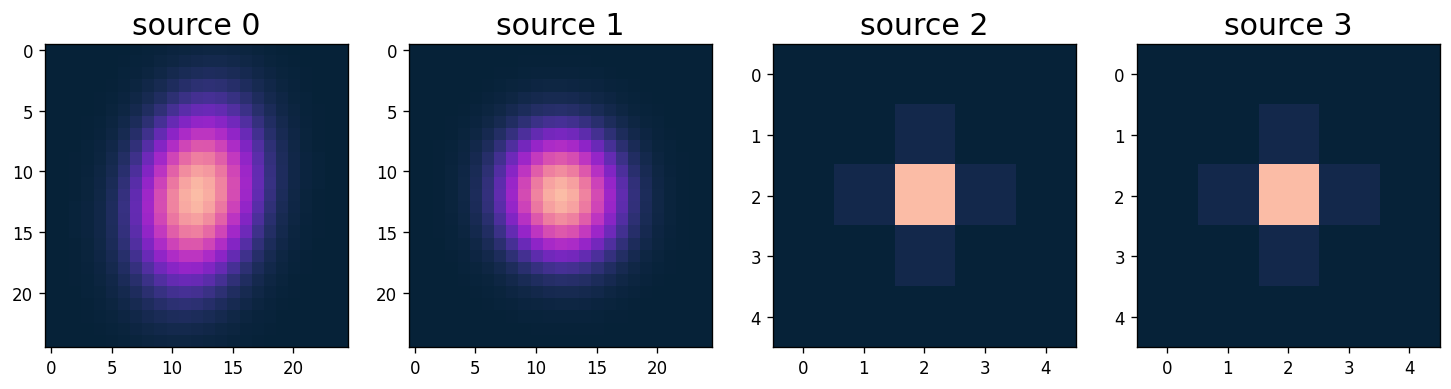

<Figure size 640x480 with 0 Axes>

In [135]:
import cmasher as cmr
cmap = cmr.bubblegum
int_method='none'
fig, axes = plt.subplots(1, len( scene.sources ), figsize=(15,6),dpi=120)
for i, ax in enumerate(axes):
    if is_extended[i]==True:#i!=indtransient:
        if isinstance(scene.sources[i].morphology, scarlet2.StarletMorphology):
             y = np.array(scene.sources[i].morphology())   #if regular morph
        else:
            y = np.array(scene.sources[i].morphology)    #If starlet morph

        # should work if it's already 2D or 3D
    else:
        y = scene.sources[i].morphology()
    ax.imshow(y, cmap = cmap,interpolation=int_method)#,vmin = np.max([np.min(np.log(y)[np.log(y)>-15]),-15]))
    ax.set_title(f"source {i}", fontsize = 18)
    ax.invert_yaxis()


# save_path = f'{additional_path}{img_index}_results/{date}/{folder}sc2_prefitting/'
# plt.savefig(save_path+str(img_index)+'_source_models'+version+'.png')

plt.show()
plt.clf()

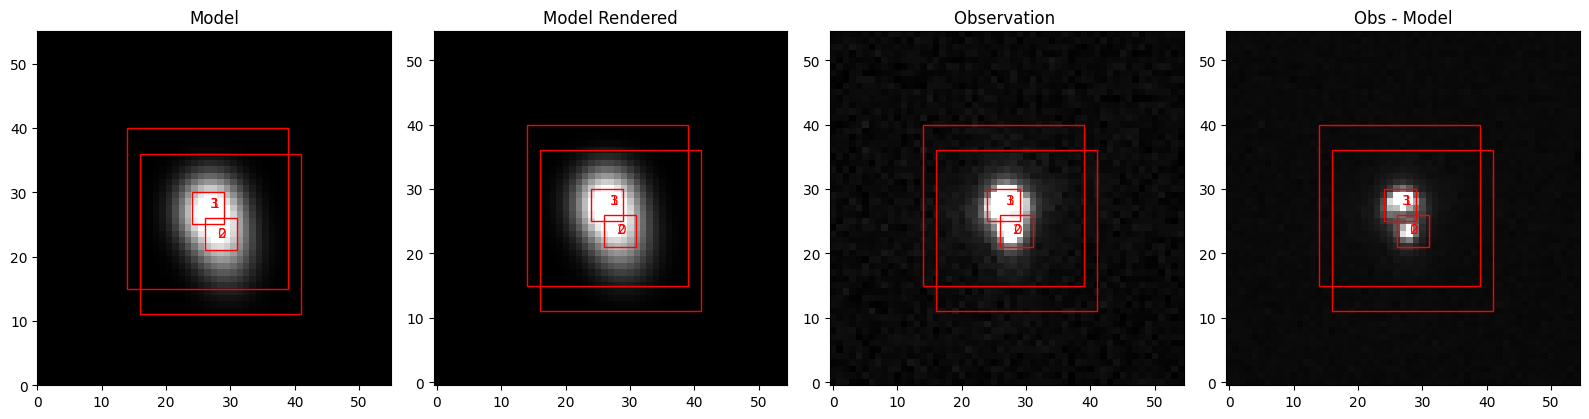

In [136]:
#print(obs_hsc.data.shape,obs_hst.data.shape)
#print(frameall.channels,channels_zeroed)
#print(obs_hsc.render(scene()).shape,obs_hst.render(scene()).shape)
scarlet2.plot.scene(
    scene,
    observation=observations_sc2[50],
    norm=None,
    show_model=True,
    show_observed=True,
    show_rendered=True,
    show_residual=True,
    add_labels=True,
    add_boxes=True,
    split_channels=False,
    box_kwargs={"edgecolor": "red", "facecolor": "none"},
    label_kwargs={"color": "red"},
)

# save_path = f'{additional_path}{img_index}_results/{date}/{folder}sc2_prefitting/'
# plt.savefig(f'{save_path}{str(img_index)}_scene_prefit_roman_0_{BANDS[0]}{version}.png')

plt.show()

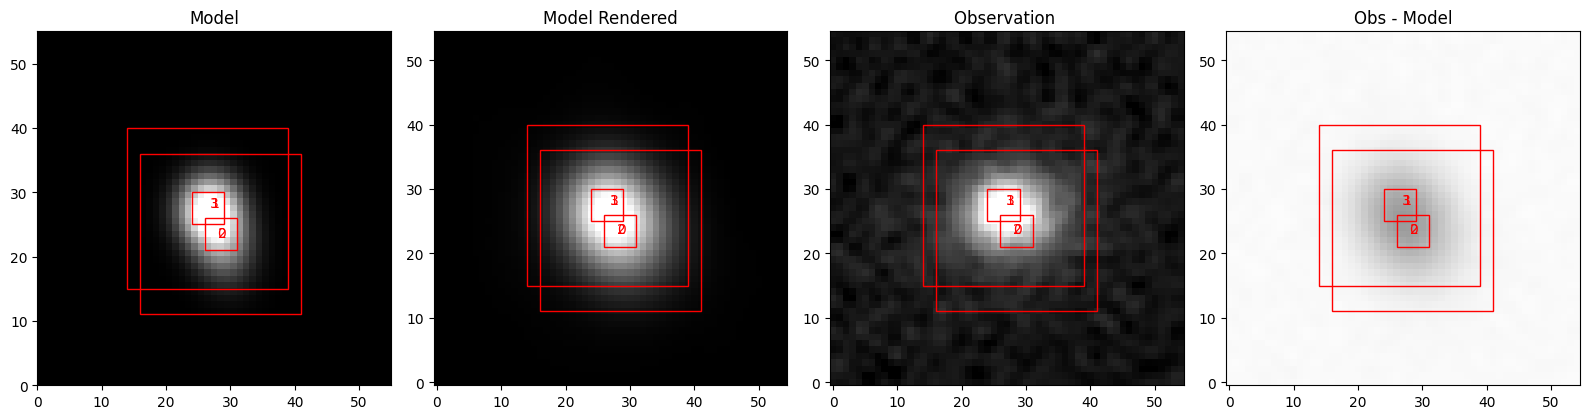

In [137]:
# Plot the model, for each epoch
scarlet2.plot.scene(
    scene,
    observation=observations_sc2[8],
    norm=None,
    show_model=True,
    show_observed=True,
    show_rendered=True,
    show_residual=True,
    add_labels=True,
    add_boxes=True,
    split_channels=False,
    box_kwargs={"edgecolor": "red", "facecolor": "none"},
    label_kwargs={"color": "red"},
)

# save_path = f'{additional_path}{img_index}_results/{date}/{folder}sc2_prefitting/'
# plt.savefig(f'{save_path}{str(img_index)}_scene_prefit_lsst_8_{bands[2]}{version}.png')

plt.show()


## Fitting

In [138]:
# for i, obs in enumerate(observations_sc2):   #[:-n_roman]):  
#     for source_indx in range(len(scene.sources)):
#         spectrum = scene.sources[source_indx].spectrum.data
#         print((1 / jnp.sqrt(obs.weights.mean(axis=(-2,-1)))).sum() / spectrum.sum())
   

In [139]:
pos_step = 1e-2
morph_step = lambda p: scarlet2.relative_step(p, factor=5e-6)    #tired 1e-5
SED_step_SN = lambda p: scarlet2.relative_step(p, factor=1e-2)
SED_step_gal = lambda p: scarlet2.relative_step(p, factor=1e-3)  #tried 1e-4

for i, obs in enumerate(observations_sc2):   #[:-n_roman]):  
    obs.check_set_renderer(model_frame)
    with scarlet2.Parameters(obs):
        scarlet2.Parameter(obs.renderer[1].shift, name=f"shift_{i}", stepsize=1e-2  * u.arcsec) #5e-2   #1e-2
    

with Parameters(scene):   #as parameters:  --> old syntax
    for source_indx in range(len(scene.sources)):
        
        ####### SPECTRUM   ##############
        if is_extended[source_indx]:
            SED_step = SED_step_gal
        else:
            SED_step = SED_step_SN
        
        scarlet2.Parameter(scene.sources[source_indx].spectrum.data, 
                                         name=f"spectrum.{source_indx}", 
                                         stepsize=SED_step,
                                         constraint=constraints.positive,   
                                        )   #are constrains supposed to be included? no in scarlet2 docs
         ####### MORPHOLOGY   ##############
        if is_extended[source_indx]:
            ### Static host galaxy parameters; or lens
            # scarlet2.Parameter(scene.sources[source_indx].morphology,   #morphology, #morphology.data or morphology.coeffs
            #                                  name=f"morph.{source_indx}", stepsize=morph_step,
            #                                  constraint=constraints.positive)#, prior=prior)

            if isinstance(scene.sources[source_indx].morphology, scarlet2.SersicMorphology):
                # lens -- Sersic parameters
                scarlet2.Parameter(
                    scene.sources[source_indx].morphology.size,
                    name=f"morphology.{source_indx}.size",
                    constraint=constraints.positive,
                    stepsize=0.05,
                )
                scarlet2.Parameter(
                    scene.sources[source_indx].morphology.ellipticity,
                    name=f"morphology.{source_indx}.eps",
                    constraint=scarlet2.constraint.unit_disk,
                    stepsize=1e-2,
                )
                scarlet2.Parameter(
                    scene.sources[source_indx].morphology.n,
                    name=f"morphology.{source_indx}.n",
                    constraint=constraints.positive,
                    stepsize=0.05,
                )
            
            
            elif isinstance(scene.sources[source_indx].morphology, scarlet2.StarletMorphology):            
            # else:  #host or StarletMorph lens
            
                coeffs = scene.sources[source_indx].morphology.coeffs
                num_scales = coeffs.shape[0]
    
                if source_indx == lens_indx:
                    fine, mid, coarse = 1e-3, 1e-2, 0.1   # tighter for compact lens
                else:
                    fine, mid, coarse = 1e-2, 0.1, 1   # slightly looser for extended host
                
                scale_list = []
                for s in range(num_scales):
                    if s == 0:
                        scale_list.append(fine)
                    elif s == num_scales - 1:
                        scale_list.append(coarse)
                    else:
                        scale_list.append(mid)
    
                
                stdev = jnp.array(scale_list, dtype=jnp.float32)
                stdev = stdev[:, None, None] * jnp.ones_like(coeffs)
                prior = dist.Cauchy(scale=stdev).to_event(coeffs.ndim)   # prior = dist.Normal(loc=0, scale=stdev).to_event(coeffs.ndim)
                
                scarlet2.Parameter(
                    scene.sources[source_indx].morphology.coeffs,
                    name=f"morph.{source_indx}",
                    prior=prior,
                    constraint=constraints.positive,   #constraint=constraints.unit_interval or .positive
                    stepsize=morph_step,
                )

            else:
                scarlet2.Parameter(scene.sources[source_indx].morphology,   #morphology, #morphology.data or morphology.coeffs
                                                 name=f"morph.{source_indx}", stepsize=morph_step,
                                                 constraint=constraints.positive)#, prior=prior)

            
            
        else:
            #Transient point source parameters
            scarlet2.Parameter(scene.sources[source_indx].center, 
                               name=f"center.{source_indx}",
                               stepsize=pos_step
                                            )
             
    

In [140]:
# for k, src in enumerate(scene.sources):
#     print("Source {}, Fluxes: {}".format(k, scarlet2.measure.flux(src)))
# print(scene.sources[1].spectrum.data)
# print(scene.sources[3].spectrum.data)

In [141]:
# Fit the scene
stepnum = 30000
# scene_ = scene.fit(observations_sc2, parameters, max_iter=stepnum, e_rel=1e-4, progress_bar=True)  #old synatx
scene_, observations_sc2_ = scarlet2.fit(scene, observations_sc2, max_iter=stepnum, e_rel=1e-7, progress_bar=True)   # e_rel = 1e-7


  0%|          | 0/30000 [00:00<?, ?it/s]

[186959.89 186959.77 186959.62 186959.5  186959.34 186959.19 186959.08
 186958.94 186958.8  186958.66 186958.52 186958.4  186958.27 186958.11
 186958.   186957.84 186957.72 186957.58 186957.44 186957.33 186957.19
 186957.03 186956.94 186956.78 186956.67 186956.5  186956.39 186956.25
 186956.11 186955.97 186955.84 186955.73 186955.58 186955.42 186955.28
 186955.11 186955.   186954.88 186954.72 186954.61 186954.44 186954.33
 186954.2  186954.05 186953.97 186953.8  186953.67 186953.5  186953.38
 186953.27 186953.14 186953.03 186952.89 186952.73 186952.56 186952.45
 186952.3  186952.17 186952.03 186951.9  186951.8  186951.64 186951.5
 186951.38 186951.22 186951.12 186950.98 186950.86 186950.73 186950.58
 186950.44 186950.33 186950.17 186950.06 186949.9  186949.77 186949.67
 186949.5  186949.38 186949.27 186949.12 186948.98 186948.81 186948.7
 186948.56 186948.45 186948.31 186948.17 186948.03 186947.88 186947.77
 186947.64 186947.47 186947.38 186947.22 186947.1  186946.95 186946.81
 186946.

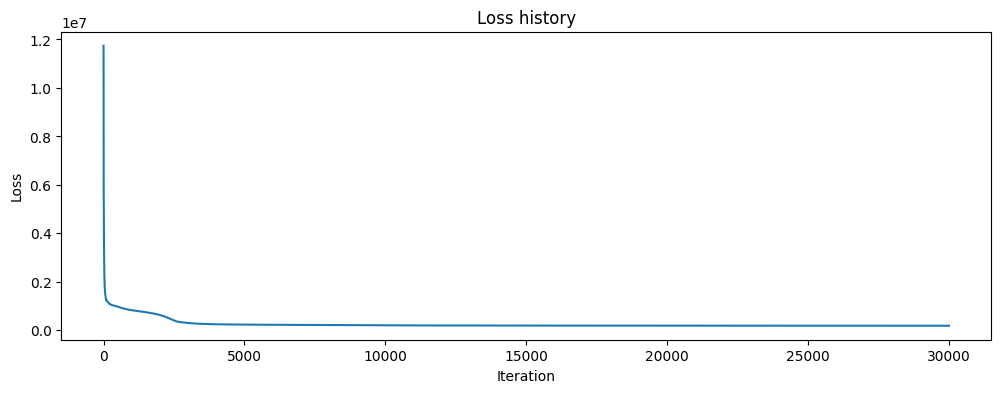

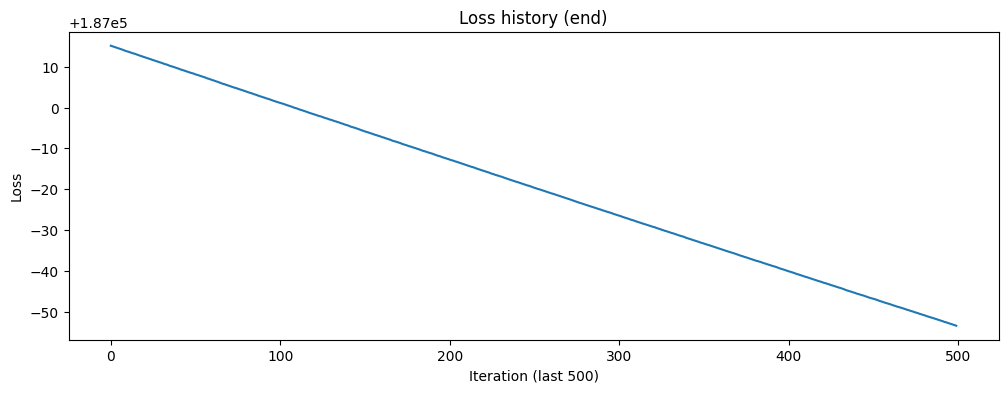

In [142]:
print(scene_.fit_info['loss'][-100:])

loss = scene_.fit_info['loss']
plt.figure(figsize=(12, 4))
plt.plot(loss)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Loss history")
plt.show()

# zoom into the last 500 iterations
plt.figure(figsize=(12, 4))
plt.plot(loss[-500:])
plt.xlabel("Iteration (last 500)")
plt.ylabel("Loss")
plt.title("Loss history (end)")
plt.show()

In [143]:
# import scarlet2.io as io
# id = 11
# filename = str(img_index) + "_scarlet2_caustics_model.h5"
# io.model_to_h5(scene_, filename, id=id, overwrite=True)

In [144]:
# import scarlet2.io as io
# id = int(str(img_index) + '01')
# print(id)
# filename = "scarlet2_models_paper.h5"
# io.model_to_h5(scene_, filename, id=id, overwrite=True)

In [145]:
# import pickle

# with open(f'scarlet2_model_{img_index}{version}.pkl', 'wb') as f:
#     pickle.dump(scene_, f)
# print(f"Saved model to scarlet2_model_{img_index}{version}.pkl")

# # with open(file_path + f'scarlet2_model_{img_index}{version}.pkl', 'rb') as f:
# #     scene_loaded = pickle.load(f)

In [146]:
# pixel scale in arcsec/pixel
model_pixel_scale = np.sqrt(np.abs(np.linalg.det(scene_.frame.wcs.pixel_scale_matrix))) * 3600

# total width in arcsec
n_pixels = scene_.frame.bbox.shape[-1]  # assuming square
total_width = n_pixels * model_pixel_scale

print(f"Pixel scale: {model_pixel_scale:.4f} arcsec/pixel")
print(f"Total width: {total_width:.4f} arcsec")


source_positions = {}
for i, src in enumerate(scene_.sources):
    theta_x = (src.center[1] * model_pixel_scale) - (total_width / 2)
    theta_y = (src.center[0] * model_pixel_scale) - (total_width / 2)
    source_positions[i] = (theta_x, theta_y)
    print(f"Source {i}: ({theta_x:.4f}, {theta_y:.4f}) arcsec")

# then compute separations between any two sources
for i in range(len(scene_.sources)):
    for j in range(i+1, len(scene_.sources)):
        dx = source_positions[i][0] - source_positions[j][0]
        dy = source_positions[i][1] - source_positions[j][1]
        sep = np.sqrt(dx**2 + dy**2)
        print(f"Separation source {i} -- source {j}: {sep:.4f} arcsec")

Pixel scale: 0.1100 arcsec/pixel
Total width: 6.0500 arcsec
Source 0: (0.0554, -0.4847) arcsec
Source 1: (-0.0727, 0.0254) arcsec
Source 2: (0.1153, -0.5801) arcsec
Source 3: (-0.1366, -0.0500) arcsec
Separation source 0 -- source 1: 0.5260 arcsec
Separation source 0 -- source 2: 0.1126 arcsec
Separation source 0 -- source 3: 0.4752 arcsec
Separation source 1 -- source 2: 0.6340 arcsec
Separation source 1 -- source 3: 0.0989 arcsec
Separation source 2 -- source 3: 0.5869 arcsec


In [147]:
## using only the Jacobian tranform between the resampled and native HSC frame
# this ignores possible frame offset because the shift is relative
# get the astrometry shift
shift = observations_sc2_[0].get("shift")
print(f"Shift in model pixels: {shift}")

for i in range(len(observations_sc2)): #[:-n_roman])):

    shift_band = observations_sc2_[i].get(f"shift_{i}")
    print(f"Obs {i} shift in model pixels: {shift_band}")
    
    obs = observations_sc2[i]
    obs_ = observations_sc2_[i]

    jacobian, _ = scarlet2.frame.get_relative_jacobian_shift(obs_.frame, obs.frame)
    shift_native = jacobian @ shift_band
    # print(f"{i}: Shift in native pixels: {shift_native}")
    
    # create the renderer for native HSC if not already there
    obs.check_set_renderer(model_frame)
    # force the renderer to use optimized value for shift
    object.__setattr__(obs.renderer[-1], "shift", shift_native)
    



Shift in model pixels: None
Obs 0 shift in model pixels: [ 0.22443022 -0.9939688 ]
Obs 1 shift in model pixels: [ 0.09944049 -0.8768252 ]
Obs 2 shift in model pixels: [-0.1603447 -0.8086246]
Obs 3 shift in model pixels: [ 0.04326444 -0.8525341 ]
Obs 4 shift in model pixels: [ 0.07035821 -0.9342044 ]
Obs 5 shift in model pixels: [ 0.17567073 -0.9259968 ]
Obs 6 shift in model pixels: [ 0.22668733 -0.9804417 ]
Obs 7 shift in model pixels: [ 0.26113877 -1.067523  ]
Obs 8 shift in model pixels: [ 0.28464448 -0.8973439 ]
Obs 9 shift in model pixels: [ 0.2006408 -0.9546095]
Obs 10 shift in model pixels: [ 0.27890638 -0.996812  ]
Obs 11 shift in model pixels: [ 0.14527015 -0.9158125 ]
Obs 12 shift in model pixels: [ 0.29025227 -0.94616973]
Obs 13 shift in model pixels: [ 0.09910239 -0.9947236 ]
Obs 14 shift in model pixels: [ 0.35350502 -0.8789008 ]
Obs 15 shift in model pixels: [ 0.3831827 -0.9691162]
Obs 16 shift in model pixels: [ 0.25584036 -0.9562032 ]
Obs 17 shift in model pixels: [ 0.09

In [148]:
def get_observation_idx(telescope, epoch, band):
    if telescope == "lsst":
        band_map = {
            bands[0]: 0,
            bands[1]: 1,
            bands[2]: 2,
        }

        epoch_offset = {
            0: 0,
            8: 8,
        }

        return epoch_offset[epoch] + 16 * band_map[band]

    elif telescope == "roman":
        band_map = {
            BANDS[0]: 0,
            BANDS[1]: 1,
            BANDS[2]: 2,
        }

        epoch_offset = {
            0: 48,
            8: 51,
        }

        return epoch_offset[epoch] + band_map[band]

    else:
        raise ValueError(f"Unknown telescope: {telescope}")

In [149]:
date = '15_07_26'
version = '_realPSF_Pixel_bothRom'
additional_path =  'sc2_results/different_separations/small_sep/'
folder = 'roman_both_epoch/'

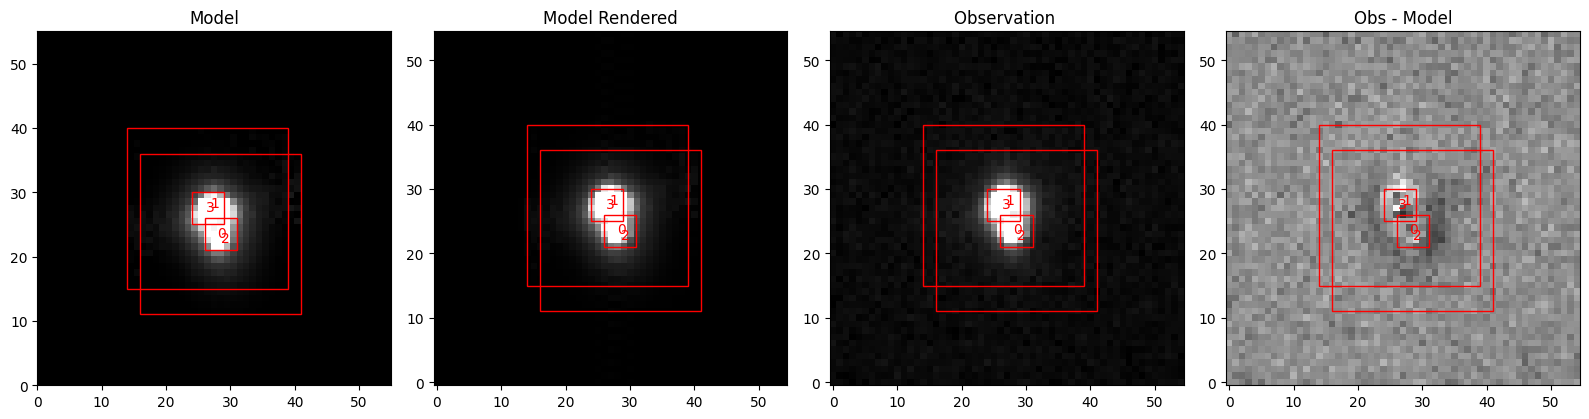

In [150]:
telescope = "roman"
epoch = 8
band = BANDS[2]

obs_idx = get_observation_idx(telescope, epoch, band)

scarlet2.plot.scene(
    scene_,
    observation=observations_sc2_[obs_idx],
    show_rendered=True,
    show_observed=True,
    show_residual=True,
    add_labels=True,
    add_boxes=True,
    norm=None,
    box_kwargs={"edgecolor": "red", "facecolor": "none"},
    label_kwargs={"color": "red"},
)

# save_path = f'{additional_path}{img_index}_results/{date}/{folder}sc2_postfitting/'
# plt.savefig(f'{save_path}{str(img_index)}_postfit_{telescope}_{str(band)}_{epoch}{version}.png')

plt.show()


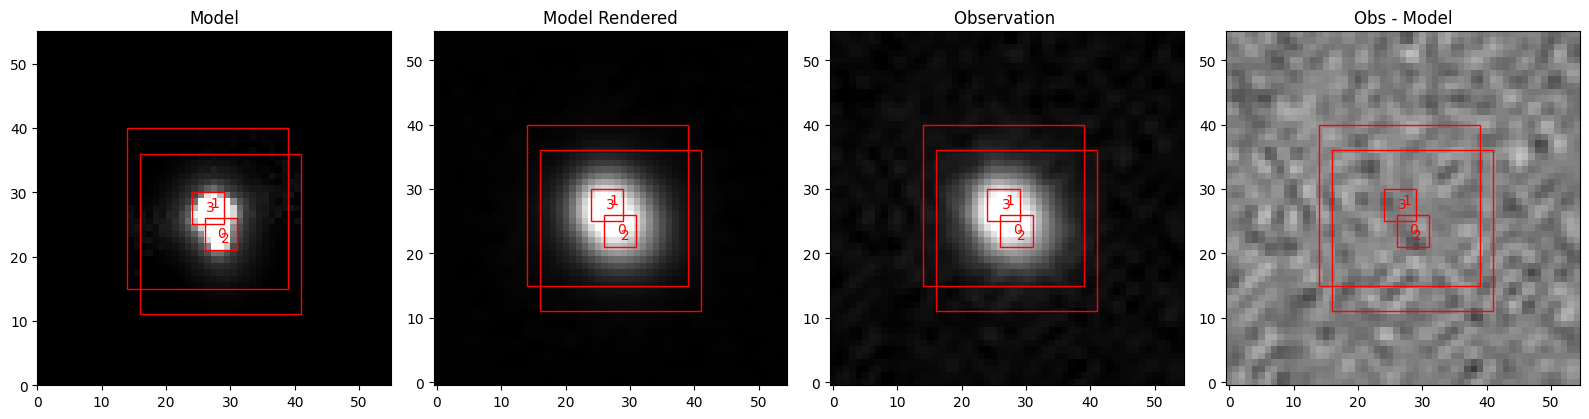

In [151]:
telescope = "lsst"
epoch = 8
band = bands[2]

obs_idx = get_observation_idx(telescope, epoch, band)

scarlet2.plot.scene(
    scene_,
    observation=observations_sc2_[obs_idx],
    show_rendered=True,
    show_observed=True,
    show_residual=True,
    add_labels=True,
    add_boxes=True,
    norm=None,
    box_kwargs={"edgecolor": "red", "facecolor": "none"},
    label_kwargs={"color": "red"},
)

# save_path = f'{additional_path}{img_index}_results/{date}/{folder}sc2_postfitting/'
# plt.savefig(f'{save_path}{str(img_index)}_postfit_{telescope}_{str(band)}_{epoch}{version}.png')

plt.show()


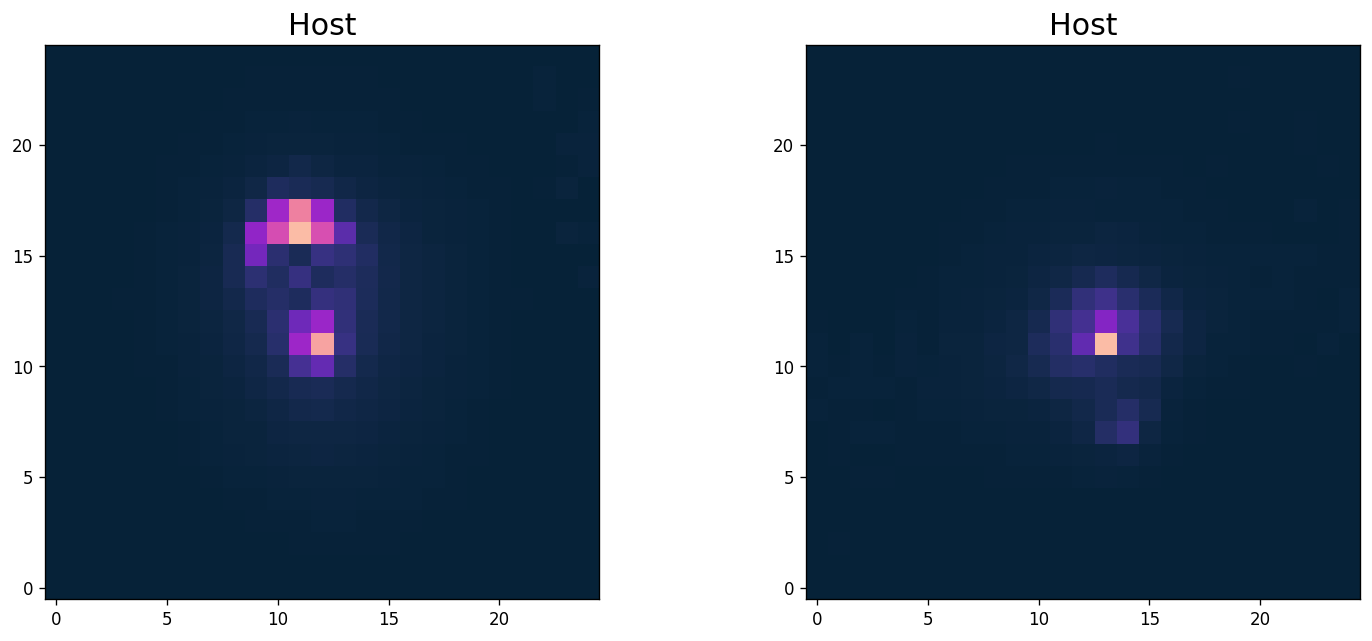

In [153]:

cmap = cmr.bubblegum
int_method='none'
# fig, axes = plt.subplots(1, len(scene_.sources), figsize=(15,6),dpi=120)

extended_indx = [i for i, ext in enumerate(is_extended) if ext]
fig, axes = plt.subplots(1, 2, figsize=(15,6),dpi=120)

for i, ax in enumerate(axes):
    source_indx = extended_indx[i]
    # if is_extended[i] == True:
    if isinstance(scene_.sources[source_indx].morphology, scarlet2.StarletMorphology):
        y = np.array(scene_.sources[source_indx].morphology())  
    else:
        y = np.array(scene_.sources[source_indx].morphology)    

    # else:
    #     y = scene_.sources[i].morphology()

    ## y_display = np.clip(y, 0, None)
    ## ax.imshow(y_display, cmap=cmap, interpolation=int_method)
    
    ax.imshow(y, cmap = cmap,interpolation=int_method)       #,vmin = np.max([np.min(np.log(y)[np.log(y)>-15]),-15]))
    if source_indx == lens_indx:
        source_title = 'Lens'
    else:
        source_title = 'Host'
    ax.set_title(f"{source_title}", fontsize = 18)

# save_path = f'{additional_path}{img_index}_results/{date}/{folder}sc2_postfitting/' 
# plt.savefig(f'{save_path}{str(img_index)}_source_models_postfit{version}.png')

plt.show()

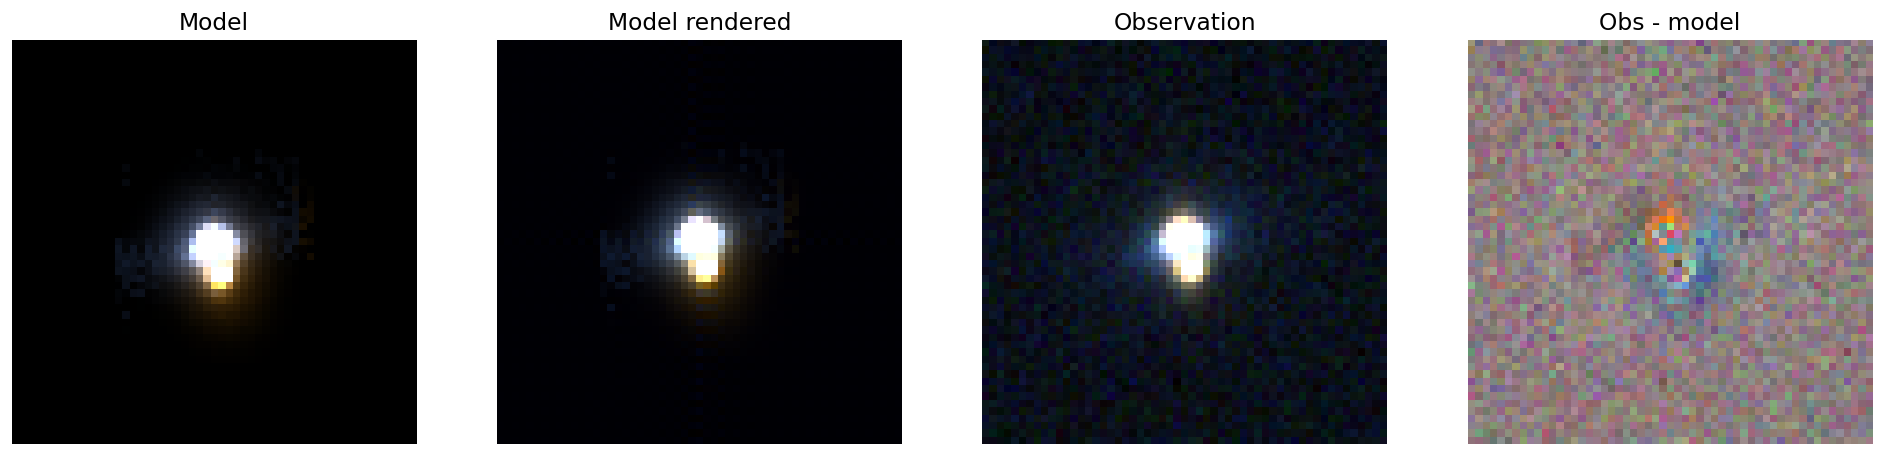

In [154]:
telescope = 'roman'
epoch = 8


if telescope == 'lsst':
    band_name = [bands[0], bands[1], bands[2]]
    if epoch == 0:
        epoch_idx = [0, 16, 32]
    elif epoch == 8:
        epoch_idx = [8, 24, 40]
elif telescope == 'roman':
    band_name = [BANDS[0], BANDS[1], BANDS[2]]
    if epoch == 0:
        epoch_idx = [48, 49, 50]
    elif epoch == 8:
        epoch_idx = [51, 52, 53]

# if telescope == 'lsst':
#     band_name = [bands[0], bands[1], bands[2]]
#     if epoch == 0:
#         epoch_idx = [0, 22, 44]
#     elif epoch == 8:
#         epoch_idx = [11, 33, 55]
# elif telescope == 'roman':
#     band_name = [BANDS[0], BANDS[1], BANDS[2]]
#     if epoch == 0:
#         epoch_idx = [66, 67, 68]
#     elif epoch == 8:
#         epoch_idx = [69, 70, 71]


# extract pre-converted RGB arrays from scarlet2.plot.scene for each band
panels = ['Model', 'Model Rendered', 'Observation', 'Obs - Model']
figs_data = {band: {} for band in ['g', 'r', 'i']}

for band, idx in zip(['g', 'r', 'i'], epoch_idx):
    fig = scarlet2.plot.scene(
        scene_,
        observation=observations_sc2[idx],
        norm=None,
        show_model=True,
        show_rendered=True,
        show_observed=True,
        show_residual=True,
        add_labels=True,
        add_boxes=True,
    )
    for panel, ax in zip(panels, fig.axes):
        figs_data[band][panel] = fig.axes[panels.index(panel)].get_images()[0].get_array().data.copy()
    plt.close(fig)

# combine i=R, r=G, g=B into color composite
fig, axes = plt.subplots(1, 4, figsize=(20, 5), dpi=120)
for ax, panel in zip(axes, panels):
    rgb = np.stack([
        figs_data['i'][panel][:, :, 0],
        figs_data['r'][panel][:, :, 0],
        figs_data['g'][panel][:, :, 0],
    ], axis=-1).astype(float) / 255.0

    ax.imshow(rgb, origin='lower')
    ax.set_title(panel.capitalize(), fontsize=14)
    ax.axis('off')

# #plt.tight_layout()

# save_path = f'{additional_path}{img_index}_results/{date}/{folder}sc2_postfitting/'
# plt.savefig(f'{save_path}{str(img_index)}_postfit_{telescope}_color_{epoch}{version}.png')

plt.show()

In [155]:
# for i, obs in enumerate(observations_sc2_):   #[:-n_roman]):  
#     for source_indx in range(len(scene_.sources)):
#         spectrum = scene_.sources[source_indx].spectrum.data
#         print((1 / jnp.sqrt(obs.weights.mean(axis=(-2,-1)))).sum() / spectrum.sum())


In [156]:
for k, src in enumerate(scene_.sources):
    print("Source {}, Fluxes: {}".format(k, scarlet2.measure.flux(src)))

Source 0, Fluxes: [ 57.654285  57.654285  57.654285  57.654285  57.654285  57.654285
  57.654285  57.654285  57.654285  57.654285  57.654285  57.654285
  57.654285  57.654285  57.654285  57.654285  58.12322   58.12322
  58.12322   58.12322   58.12322   58.12322   58.12322   58.12322
  58.12322   58.12322   58.12322   58.12322   58.12322   58.12322
  58.12322   58.12322   79.05534   79.05534   79.05534   79.05534
  79.05534   79.05534   79.05534   79.05534   79.05534   79.05534
  79.05534   79.05534   79.05534   79.05534   79.05534   79.05534
  15.027086 198.91539  267.96173   15.027086 198.91539  267.96173 ]
Source 1, Fluxes: [ 55.221706  55.221706  55.221706  55.221706  55.221706  55.221706
  55.221706  55.221706  55.221706  55.221706  55.221706  55.221706
  55.221706  55.221706  55.221706  55.221706  48.19412   48.19412
  48.19412   48.19412   48.19412   48.19412   48.19412   48.19412
  48.19412   48.19412   48.19412   48.19412   48.19412   48.19412
  48.19412   48.19412   59.593086 

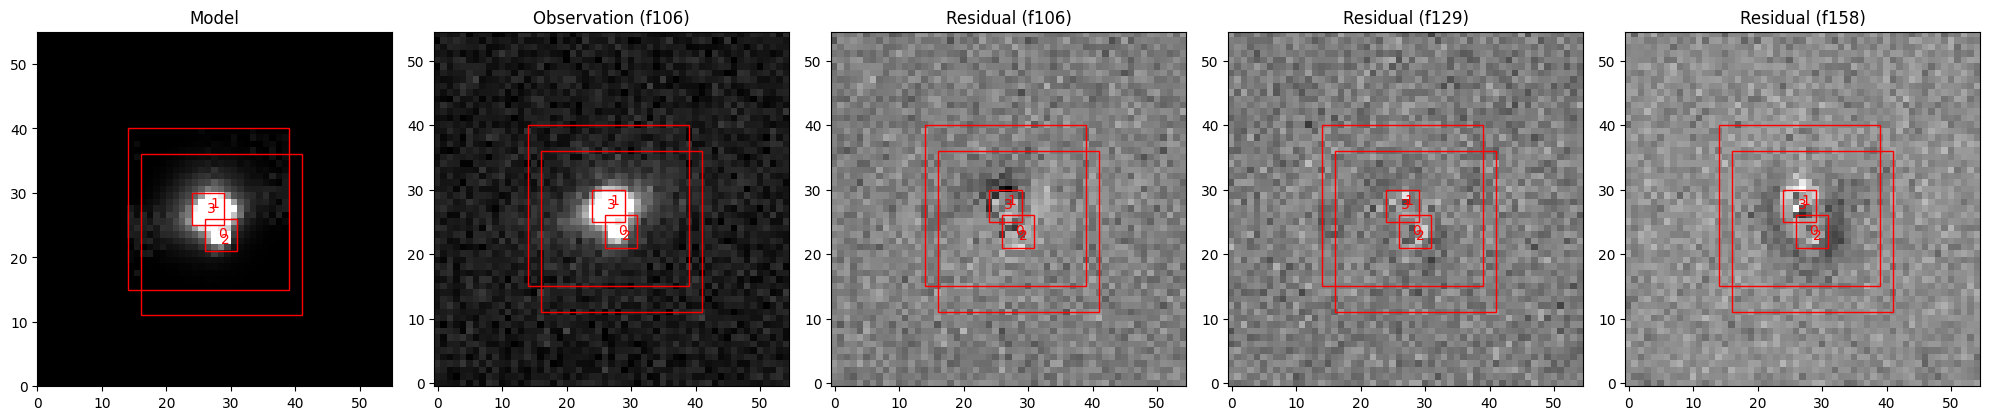

In [157]:
from scarlet2.plot import ChannelRenderer, img_to_rgb, LinearPercentileNorm
from matplotlib.patches import Polygon


telescope = 'roman'
epoch = 8

if telescope == 'lsst':
    band_name = [bands[0], bands[1], bands[2]]
    if epoch == 0:
        epoch_idx = [0, 16, 32]
    elif epoch ==8:
        epoch_idx = [8, 24, 40]
elif telescope == 'roman':
    band_name = [BANDS[0], BANDS[1], BANDS[2]]
    if epoch == 0:
        epoch_idx = [48, 49, 50]
    elif epoch == 8:
        epoch_idx = [51, 52, 53]

subplot_specs = [
    {"type": "model",    "scene": scene_, "observation": observations_sc2[epoch_idx[0]]},
    {"type": "observed", "scene": scene_, "observation": observations_sc2[epoch_idx[0]], "title": f"Observation ({band_name[0]})"},
    {"type": "residual", "scene": scene_, "observation": observations_sc2[epoch_idx[0]], "title": f"Residual ({band_name[0]})"},
    {"type": "residual", "scene": scene_, "observation": observations_sc2[epoch_idx[1]], "title": f"Residual ({band_name[1]})"},
    {"type": "residual", "scene": scene_, "observation": observations_sc2[epoch_idx[2]], "title": f"Residual ({band_name[2]})"},
]

norm         = None
channel_map  = None
add_labels   = True
add_boxes    = True
title_kwargs = {}
label_kwargs = {"color": "red"}
box_kwargs   = {"facecolor": "none", "edgecolor": "red"}
panel_size = 4  # inches per panel, adjust as needed

panels  = len(subplot_specs)
fig, ax = plt.subplots(1, panels, figsize=(panel_size * panels, panel_size), squeeze=False)

for panel, spec in enumerate(subplot_specs):
    ptype        = spec["type"]
    scene        = spec["scene"]
    observation  = spec.get("observation", None)
    custom_title = spec.get("title", None)
    model        = scene()

    if ptype == "model":
        if observation is not None:
            c = ChannelRenderer(scene.frame, observation.frame)
            display = c(model)
        else:
            display = model
        extent = scene.frame.bbox.get_extent()
        ax[0, panel].imshow(img_to_rgb(display, norm=norm, channel_map=channel_map), extent=extent, origin="lower")
        ax[0, panel].set_title(custom_title or "Model")

    elif ptype == "rendered":
        observation.check_set_renderer(scene.frame)
        model_rendered = observation.render(model)
        ax[0, panel].imshow(img_to_rgb(model_rendered, norm=norm, channel_map=channel_map), origin="lower")
        ax[0, panel].set_title(custom_title or "Model Rendered")

    elif ptype == "observed":
        data  = observation.data
        mask  = observation.weights == 0
        mask_ = np.sum(mask, axis=0) > 0
        mask_ = None if np.all(mask_ == 0) else mask_
        ax[0, panel].imshow(img_to_rgb(data, norm=norm, channel_map=channel_map, mask=mask_), origin="lower")
        ax[0, panel].set_title(custom_title or "Observation")

    elif ptype == "residual":
        observation.check_set_renderer(scene.frame)
        model_rendered = observation.render(model)
        data  = observation.data
        mask  = observation.weights == 0
        mask_ = np.sum(mask, axis=0) > 0
        mask_ = None if np.all(mask_ == 0) else mask_
        residual = data - model_rendered
        norm_    = LinearPercentileNorm(residual)
        ax[0, panel].imshow(img_to_rgb(residual, norm=norm_, channel_map=channel_map, mask=mask_), origin="lower")
        ax[0, panel].set_title(custom_title or "Obs - Model")

    for k, src in enumerate(scene.sources):
        if add_boxes:
            start, stop = src.bbox.spatial.start, src.bbox.spatial.stop
            corners = jnp.array([start, jnp.array((start[0], stop[1])), stop, jnp.array((stop[0], start[1]))])
            corners_ = observation.frame.get_pixel(scene.frame.get_sky_coord(corners))
            poly = Polygon(corners_[:, ::-1], closed=True, **box_kwargs)
            ax[0, panel].add_artist(poly)
        if add_labels:
            center  = src.center
            center_ = observation.frame.get_pixel(scene.frame.get_sky_coord(center)).flatten()
            ax[0, panel].text(*(center_[::-1]), k, **label_kwargs)

fig.tight_layout()

# save_path = f'{additional_path}{img_index}_results/{date}/{folder}sc2_postfitting/'
# plt.savefig(f'{save_path}{str(img_index)}_postfit_{telescope}_band_comparison_{epoch}{version}.png')

plt.show()

In [158]:
# lens_model = scene_.evaluate_source(scene_.sources[lens_indx])
# print(lens_model.shape)
# plt.imshow(np.array(lens_model)[0], cmap=cmap)  # may need [0] if it has a channel axis
# plt.title("Lens model contribution to full scene")
# plt.colorbar()
# plt.show()

In [163]:
import pickle

reverse_source_order = False  

# Get indices of (band, epoch) for each Rubin band
band_epoch_indices = {band: [] for band in bands}
for idx, (band, epoch) in enumerate(channels):
    if band in bands:
        band_epoch_indices[band].append((int(epoch), idx))

# Get indices of point sources (is_extended == False)
point_source_indices = [i for i, ext in enumerate(is_extended) if not ext]
if reverse_source_order:
    point_source_indices = point_source_indices[::-1]

num_point_sources = len(point_source_indices)

# Determine the number of epochs per band
max_epochs = {
    band: max(epoch for epoch, _ in indices) + 1
    for band, indices in band_epoch_indices.items()
}

# Initialize output flux structure: bands × epochs × sources
flux_array = {
    band: [[0.0 for _ in range(num_point_sources)] for _ in range(max_epochs[band])]
    for band in bands
}

# Fill in the flux values for only point sources
for local_idx, src_idx in enumerate(point_source_indices):
    fluxes = scarlet2.measure.flux(scene_.sources[src_idx])
    for band in bands:
        for epoch, flux_idx in band_epoch_indices[band]:
            flux_array[band][epoch][local_idx] = fluxes[flux_idx]

# Convert to final nested array format
output_array = [flux_array[band] for band in bands]
print(output_array)

# Save to file
file_path = 'fluxes_files/scarlet_deblended_flux/apj_paper/'
with open(f'{file_path}rubin_scarlet_caustics_fluxes_{str(img_index)}{str(version)}.pkl', "wb") as f:
    pickle.dump(output_array, f)

# print(f"Saved times array to rubin_times_{img_index}{version}.txt")

[[[Array(0., dtype=float32), Array(0., dtype=float32)], [Array(0.00054155, dtype=float32), Array(0.00069453, dtype=float32)], [Array(0.00816645, dtype=float32), Array(5.5083394, dtype=float32)], [Array(0.00460104, dtype=float32), Array(8.05021, dtype=float32)], [Array(0.00194364, dtype=float32), Array(7.269191, dtype=float32)], [Array(0.00759686, dtype=float32), Array(8.613275, dtype=float32)], [Array(0.00122213, dtype=float32), Array(0.00362457, dtype=float32)], [Array(0.00106063, dtype=float32), Array(0.00223266, dtype=float32)], [Array(0.00065364, dtype=float32), Array(0.00114061, dtype=float32)], [Array(0.00053097, dtype=float32), Array(0.0008203, dtype=float32)], [Array(0.00059725, dtype=float32), Array(0.00107488, dtype=float32)], [Array(0.0006757, dtype=float32), Array(0.00095033, dtype=float32)], [Array(0.00050643, dtype=float32), Array(0.00072425, dtype=float32)], [Array(0.00064083, dtype=float32), Array(0.0010509, dtype=float32)], [Array(0., dtype=float32), Array(0., dtype=fl

In [160]:
# import pickle


# # Define Rubin bands of interest
# rubin_bands = ['g', 'r', 'i']

# # Get indices of (band, epoch) for each Rubin band
# band_epoch_indices = {band: [] for band in rubin_bands}
# for idx, (band, epoch) in enumerate(channels):
#     if band in rubin_bands:
#         band_epoch_indices[band].append((int(epoch), idx))

# # Get indices of point sources (is_extended == False)
# point_source_indices = [i for i, ext in enumerate(is_extended) if not ext]
# num_point_sources = len(point_source_indices)

# # Determine the number of epochs per band
# max_epochs = {
#     band: max(epoch for epoch, _ in indices) + 1
#     for band, indices in band_epoch_indices.items()
# }

# # Initialize output flux structure: bands × epochs × sources
# flux_array = {
#     band: [[0.0 for _ in range(num_point_sources)] for _ in range(max_epochs[band])]
#     for band in rubin_bands
# }

# # Fill in the flux values for only point sources
# for local_idx, src_idx in enumerate(point_source_indices):
#     fluxes = scarlet2.measure.flux(scene_.sources[src_idx])
#     for band in rubin_bands:
#         for epoch, flux_idx in band_epoch_indices[band]:
#             flux_array[band][epoch][local_idx] = fluxes[flux_idx]

# # Convert to final nested array format
# output_array = [flux_array[band] for band in rubin_bands]

# print(output_array)

# #Save to file
# file_path = 'fluxes_files/scarlet_deblended_flux/'
# with open(file_path+'rubin_scarlet_caustics_fluxes_'+str(img_index)+str(version)+'.pkl', "wb") as f:
#     pickle.dump(output_array, f)

# #save txt with times used
# #  np.savetxt(f"rubin_scarlet_caustics_times_{img_index}{version}.txt", times, fmt="%.6f")
# print(f"Saved times array to rubin_times_{img_index}{version}.txt")





In [161]:
print(np.array(output_array)[2].shape)

(16, 2)


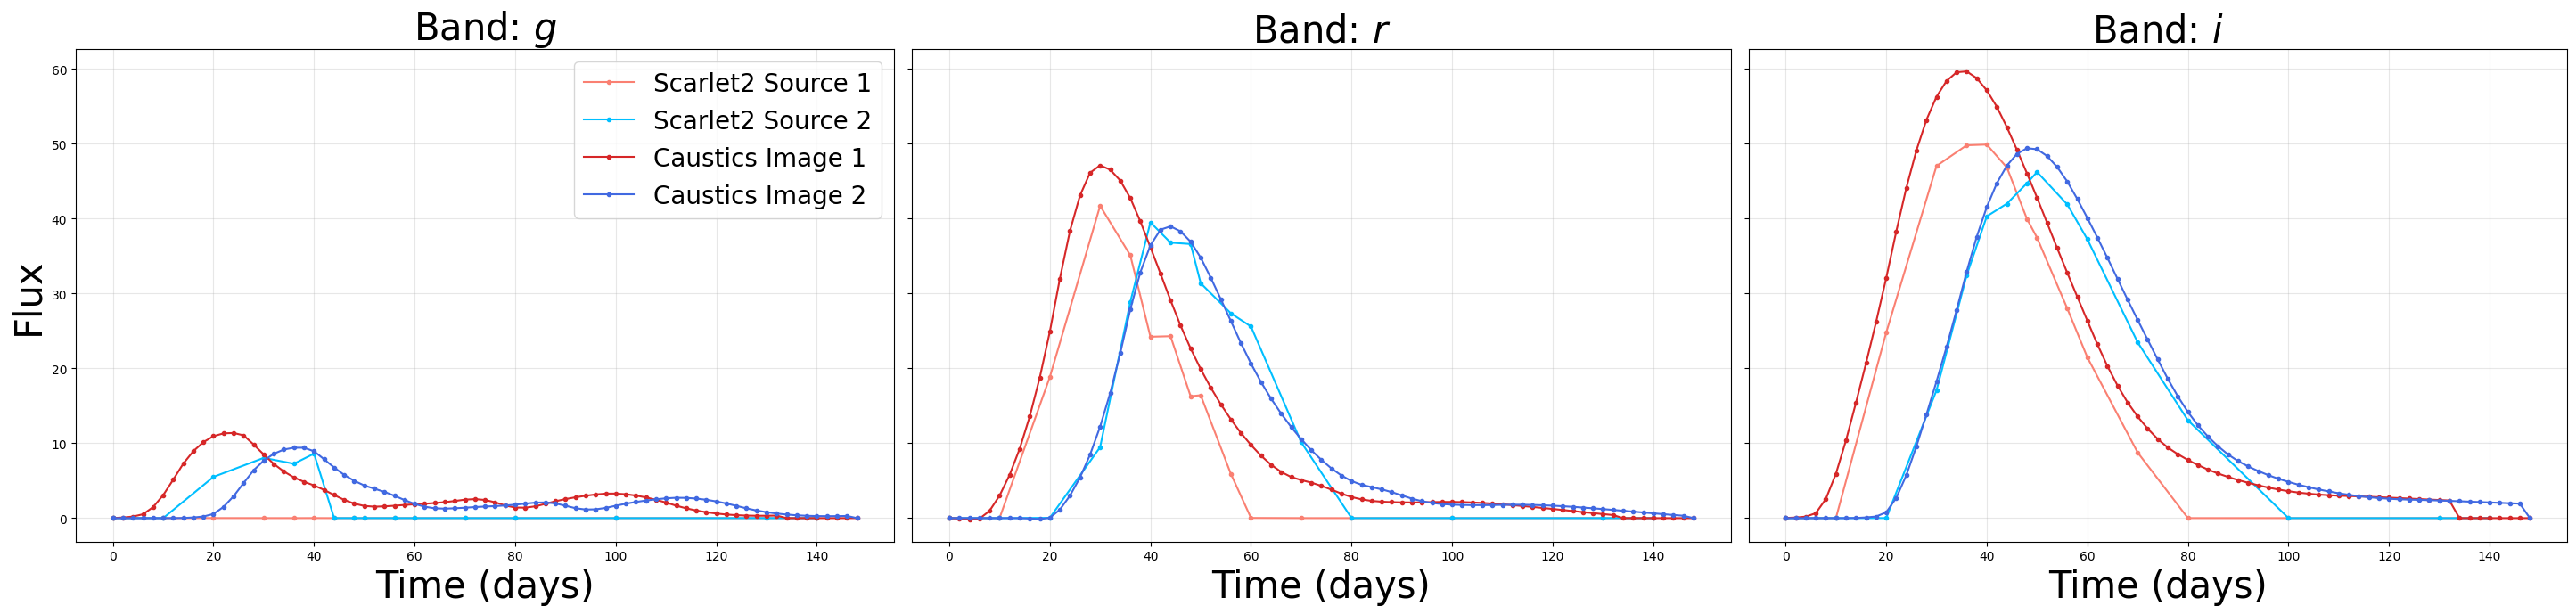

In [162]:
import pickle

with open('fluxes_files/caustics_flux/caustics_fluxes_'+str(img_index)+'_14_04_26'+'.pkl', "rb") as caustics_f:
    caustics_fluxes = pickle.load(caustics_f)
caustics_times = np.arange(0, 150, 2) 

# sc_times = [0, 10, 20, 30, 36, 40, 44, 48, 50, 56, 60, 70, 80, 100, 130, 140]
sc_times = times

fig, axes = plt.subplots(1, 3, figsize=(29, 7), sharey=True)
caustics_colors = ['tab:red', 'royalblue']
sc_colors = ['salmon', 'deepskyblue']
band_names_plot = [r'$g$', r'$r$', r'$i$']

for band_indx, band in enumerate(bands):
    ax = axes[band_indx]
    n_caustics_epochs = len(caustics_fluxes[band_indx])
    sc_epochs = sorted(set(epoch for epoch, _ in band_epoch_indices[band]))

    for local_idx in range(num_point_sources):
        sc_flux = np.array([flux_array[band][epoch][local_idx] for epoch in sc_epochs])
        ax.plot(sc_times, sc_flux, marker='o', markersize=3,
                label=f'Scarlet2 Source {local_idx+1}', color=sc_colors[local_idx])

    for local_idx in range(num_point_sources):
        caustics_flux = np.array([caustics_fluxes[band_indx][t][num_point_sources - 1 - local_idx]
                                  for t in range(n_caustics_epochs)])
        ax.plot(caustics_times, caustics_flux, marker='o', markersize=3,
                label=f'Caustics Image {local_idx+1}', color=caustics_colors[local_idx])

    ax.set_title(f'Band: {band_names_plot[band_indx]}', fontsize=30)
    ax.set_xlabel('Time (days)', fontsize=30)
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Flux', fontsize=30)
axes[0].legend(loc='upper right', fontsize=20)
# fig.suptitle('System ' + str(img_index) + r', $\Delta t = $' + td, fontsize=30)
plt.tight_layout()
plt.show()

## Get variance of residuals

In [70]:
# --- Setup indices (Same as before) ---
rubin_bands = ['g', 'r', 'i'] 

# Point sources only
point_source_indices = [i for i, ext in enumerate(is_extended) if not ext]

# Map (band, epoch) -> channel index
band_epoch_indices = {band: [] for band in rubin_bands}
for ch_idx, (band, epoch) in enumerate(channels):
    if band in rubin_bands:
        band_epoch_indices[band].append((int(epoch), ch_idx))

max_epochs = {
    band: max(e for e, _ in idxs) + 1 if idxs else 0
    for band, idxs in band_epoch_indices.items()
}

def compute_flux_error_array(scene, observations, point_source_indices,
                             rubin_bands, channels, max_epochs):
    
    # Initialize: bands × epochs × sources
    err_array = {
        band: [[0.0 for _ in range(len(point_source_indices))]
               for _ in range(max_epochs[band])]
        for band in rubin_bands
    }

    # Generate the model once
    model = scene()

    # --- FIX: Loop over the observations list directly ---
    # Assuming 'observations' list aligns with 'channels' list 1-to-1
    for ch_idx, obs in enumerate(observations):
        
        # Get metadata for this specific observation
        band, epoch = channels[ch_idx]
        epoch = int(epoch)
        
        # Skip if not a band we care about
        if band not in rubin_bands:
            continue

        # 1. Render and Compute Residual for THIS observation
        try:
            model_rendered = obs.render(model)
            residual = obs.data - model_rendered
            # Note: obs.data usually (C, Y, X). For single obs, C=0 often.
            
            # If residual is (1, Y, X), grab the 2D image
            if residual.ndim == 3:
                residual_img = residual[0]
                if hasattr(obs, "weights"):
                    weight_img = obs.weights[0]
                else:
                    weight_img = np.ones_like(residual_img)
            else:
                residual_img = residual
                weight_img = np.ones_like(residual)

            ny, nx = residual_img.shape

            # 2. Loop over sources to measure variance in this specific frame
            for local_idx, src_idx in enumerate(point_source_indices):
                src = scene.sources[src_idx]

                # -- Bounding Box Logic --
                start, stop = src.bbox.spatial.start, src.bbox.spatial.stop
                
                # Create corners in Model Frame
                corners = jnp.array([
                    start,
                    jnp.array((start[0], stop[1])),
                    stop,
                    jnp.array((stop[0], start[1])),
                ])
                
                # Transform corners to Observation Frame (Pixel coordinates)
                corners_obs = obs.frame.get_pixel(scene.frame.get_sky_coord(corners))
                ys = np.array(corners_obs[:, 0])
                xs = np.array(corners_obs[:, 1])

                # Get integer bounds
                y0, y1 = int(np.floor(ys.min())), int(np.ceil(ys.max()))
                x0, x1 = int(np.floor(xs.min())), int(np.ceil(xs.max()))

                # Clip to image bounds
                y0 = max(0, y0); y1 = min(ny, y1)
                x0 = max(0, x0); x1 = min(nx, x1)

                # Check if source is valid in this frame
                if y1 <= y0 or x1 <= x0:
                    err_array[band][epoch][local_idx] = 1e10
                    continue

                # Extract cutout
                patch = np.array(residual_img[y0:y1, x0:x1])
                w_patch = np.array(weight_img[y0:y1, x0:x1])

                # Filter for valid pixels
                valid_pixels = patch[w_patch > 0]

                if valid_pixels.size == 0:
                    flux_err = 1e10
                else:
                    # 1) Variance per pixel
                    pixel_var = np.var(valid_pixels)
                    
                    # 2) Flux Error = sqrt(N * sigma^2)
                    # N should be the number of valid pixels contributing to the sum
                    N = valid_pixels.size
                    flux_err = float(np.sqrt(N * pixel_var))

                err_array[band][epoch][local_idx] = flux_err

        except Exception as e:
            print(f"Error processing obs {ch_idx} ({band} {epoch}): {e}")
            # Fill defaults for this whole epoch if render fails
            for local_idx in range(len(point_source_indices)):
                err_array[band][epoch][local_idx] = 1e10

    # Reformat dictionary to list
    final_error_array = [err_array[band] for band in rubin_bands]
    return final_error_array

# --- Execution ---
error_array = compute_flux_error_array(
    scene_,
    observations_sc2, # Pass the full list
    point_source_indices,
    rubin_bands,
    channels,         # Pass channels to map list index to band/epoch
    max_epochs
)

# file_path = 'fluxes_files/scarlet_deblended_flux_errors/'
# with open(f"{file_path}rubin_scarlet_caustics_errors_{img_index}{version}.pkl", "wb") as f:
#     pickle.dump(error_array, f)

# print("Saved flux errors.")

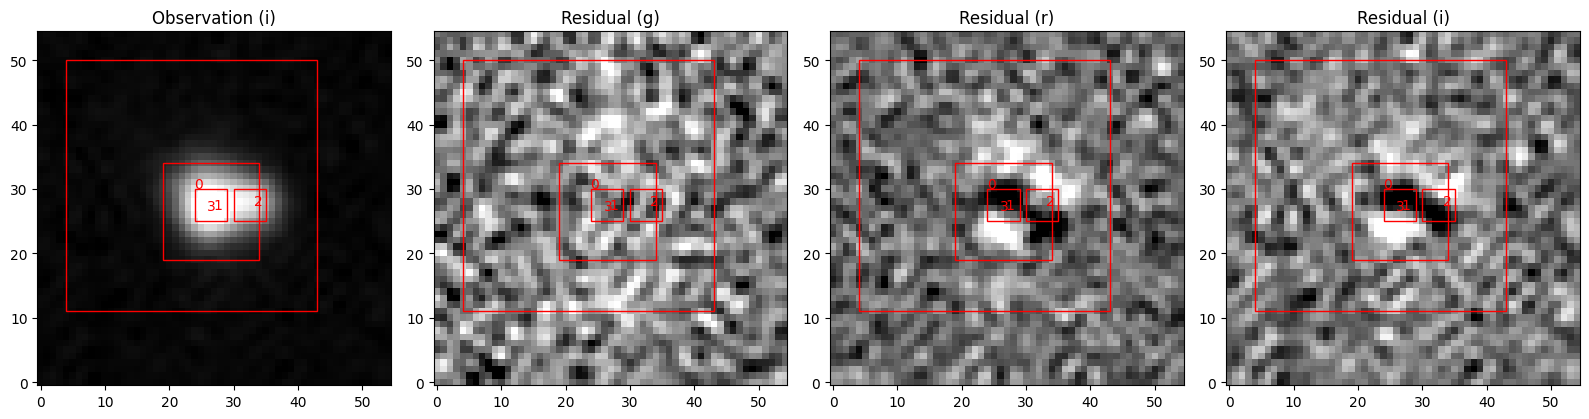

In [77]:
from scarlet2.plot import ChannelRenderer, img_to_rgb, LinearPercentileNorm
from matplotlib.patches import Polygon


telescope = 'lsst'
epoch = 8

if telescope == 'lsst':
    band_name = [bands[0], bands[1], bands[2]]
    if epoch == 0:
        epoch_idx = [0, 16, 32]
    elif epoch ==8:
        epoch_idx = [8, 24, 40]
elif telescope == 'roman':
    band_name = [BANDS[0], BANDS[1], BANDS[2]]
    if epoch == 0:
        epoch_idx = [48, 49, 50]
    elif epoch ==8:
        epoch_idx = [51, 51, 53]

subplot_specs = [
    # {"type": "model",    "scene": scene_, "observation": observations_sc2[0]},
    {"type": "observed", "scene": scene_, "observation": observations_sc2[epoch_idx[2]], "title": f"Observation ({band_name[2]})"},
    {"type": "residual", "scene": scene_, "observation": observations_sc2[epoch_idx[0]], "title": f"Residual ({band_name[0]})"},
    {"type": "residual", "scene": scene_, "observation": observations_sc2[epoch_idx[1]], "title": f"Residual ({band_name[1]})"},
    {"type": "residual", "scene": scene_, "observation": observations_sc2[epoch_idx[2]], "title": f"Residual ({band_name[2]})"},
]

norm         = None
channel_map  = None
add_labels   = True
add_boxes    = True
title_kwargs = {}
label_kwargs = {"color": "red"}
box_kwargs   = {"facecolor": "none", "edgecolor": "red"}
panel_size = 4  # inches per panel, adjust as needed

panels  = len(subplot_specs)
fig, ax = plt.subplots(1, panels, figsize=(panel_size * panels, panel_size), squeeze=False)

for panel, spec in enumerate(subplot_specs):
    ptype        = spec["type"]
    scene        = spec["scene"]
    observation  = spec.get("observation", None)
    custom_title = spec.get("title", None)
    model        = scene()

    if ptype == "model":
        if observation is not None:
            c = ChannelRenderer(scene.frame, observation.frame)
            display = c(model)
        else:
            display = model
        extent = scene.frame.bbox.get_extent()
        ax[0, panel].imshow(img_to_rgb(display, norm=norm, channel_map=channel_map), extent=extent, origin="lower")
        ax[0, panel].set_title(custom_title or "Model")

    elif ptype == "rendered":
        observation.check_set_renderer(scene.frame)
        model_rendered = observation.render(model)
        ax[0, panel].imshow(img_to_rgb(model_rendered, norm=norm, channel_map=channel_map), origin="lower")
        ax[0, panel].set_title(custom_title or "Model Rendered")

    elif ptype == "observed":
        data  = observation.data
        mask  = observation.weights == 0
        mask_ = np.sum(mask, axis=0) > 0
        mask_ = None if np.all(mask_ == 0) else mask_
        ax[0, panel].imshow(img_to_rgb(data, norm=norm, channel_map=channel_map, mask=mask_), origin="lower")
        ax[0, panel].set_title(custom_title or "Observation")

    elif ptype == "residual":
        observation.check_set_renderer(scene.frame)
        model_rendered = observation.render(model)
        data  = observation.data
        mask  = observation.weights == 0
        mask_ = np.sum(mask, axis=0) > 0
        mask_ = None if np.all(mask_ == 0) else mask_
        residual = data - model_rendered
        norm_    = LinearPercentileNorm(residual)
        ax[0, panel].imshow(img_to_rgb(residual, norm=norm_, channel_map=channel_map, mask=mask_), origin="lower")
        ax[0, panel].set_title(custom_title or "Obs - Model")

    for k, src in enumerate(scene.sources):
        if add_boxes:
            start, stop = src.bbox.spatial.start, src.bbox.spatial.stop
            corners = jnp.array([start, jnp.array((start[0], stop[1])), stop, jnp.array((stop[0], start[1]))])
            corners_ = observation.frame.get_pixel(scene.frame.get_sky_coord(corners))
            poly = Polygon(corners_[:, ::-1], closed=True, **box_kwargs)
            ax[0, panel].add_artist(poly)
        if add_labels:
            center  = src.center
            center_ = observation.frame.get_pixel(scene.frame.get_sky_coord(center)).flatten()
            ax[0, panel].text(*(center_[::-1]), k, **label_kwargs)

# fig.tight_layout()
# save_path = f'{additional_path}{img_index}_results/{date}/{folder}sc2_postfitting/'
# plt.savefig(f'{save_path}{str(img_index)}_postfit_{telescope}_band_comparison_8{version}_.png')
# plt.show()